# Complete DSA Degree-to-Job Market Analysis

This notebook performs end-to-end analysis:
1. **Fetch & embed NUS module descriptions** from NUSMods API
2. **Global BERTopic clustering** of entire job market
3. **Approval voting** to rank jobs by DSA relevance
4. **Visualize similarity curve + Kneedle elbow detection** (plots first, then decides)
5. **Module analysis**: relevance (depth), breadth, and transferability
6. **Generate comprehensive visualizations**

**Note**: This notebook does everything in one go - no need to run separate notebooks!

## Configuration & File Paths

In [160]:
import os

# ============================================
# INPUT FILES
# ============================================
INPUT_CSV = os.path.join("..", "nus_courses.csv")
JOBS_PARQUET = os.path.join("..", "outputs", "processed_jobs_dual_embeddings.parquet")
PREREQ_COUNTS_CSV = os.path.join("..", "outputs", "mod_importance", "data_sci_analytics_counts.csv")

# ============================================
# OUTPUT DIRECTORIES
# ============================================
ALL_MODULES_PARQUET = os.path.join("..", "outputs", "10_nus_modules_embedded.parquet")
GLOBAL_OUTPUT_DIR = os.path.join("..", "outputs", "bertopic_visualizations_global")

# Degree-specific analysis directory
TARGET_DEGREE = "data_sci_analytics"
DEGREE_OUTPUT_DIR = os.path.join("..", "outputs", "analysis_results", "nus", TARGET_DEGREE)
MODULE_ANALYSIS_DIR = DEGREE_OUTPUT_DIR
VIZ_DIR = os.path.join(DEGREE_OUTPUT_DIR, "visualizations")

# Create directories
os.makedirs(GLOBAL_OUTPUT_DIR, exist_ok=True)
os.makedirs(MODULE_ANALYSIS_DIR, exist_ok=True)
os.makedirs(VIZ_DIR, exist_ok=True)

# ============================================
# PARAMETERS
# ============================================
START_YEAR = 2025  # Starting year for NUSMods API (AY2025-2026 only)

print("Configuration loaded!")
print(f"Target degree: {TARGET_DEGREE}")
print(f"Degree output: {DEGREE_OUTPUT_DIR}")
print(f"Input CSV: {INPUT_CSV}")
print(f"Jobs data: {JOBS_PARQUET}")
print("\nNote: All similarity thresholds are data-driven (no hardcoded values)")

Configuration loaded!
Target degree: data_sci_analytics
Degree output: ../outputs/analysis_results/nus/data_sci_analytics
Input CSV: ../nus_courses.csv
Jobs data: ../outputs/processed_jobs_dual_embeddings.parquet

Note: All similarity thresholds are data-driven (no hardcoded values)


## Import Libraries

In [161]:
import pandas as pd
import numpy as np
import requests
import time
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance
import optuna
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("husl")

# Stop words
job_fluff = ["job", "description", "apply", "candidates", "interested", "hiring",
    "qualifications", "preferred", "required", "responsibilities", "equivalent", 
    "company", "opportunities", "role", "title", "experience", "years", "year", 
    "skills", "work", "working", "team", "teams", "knowledge", "ability", "strong", 
    "using", "understanding", "including", "related", "key", "help", "plus"]
all_stop_words = list(ENGLISH_STOP_WORDS) + job_fluff

print("All libraries imported!")

All libraries imported!


---
# PART 0: Fetch & Embed NUS Modules
Fetch module descriptions from NUSMods API and embed them with MPNet

In [162]:
print("="*80)
print("PART 0: FETCHING & EMBEDDING NUS MODULES")
print("="*80)

# API fetcher function - ONLY 2025-2026, no fallback
def fetch_module_data(mod_code, year=2025):
    url = f"https://api.nusmods.com/v2/{year}-{year+1}/modules/{mod_code.upper()}.json"
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            d = r.json()
            return {
                "code": mod_code,
                "title": d.get("title", ""),
                "description": d.get("description", ""),
                "faculty": d.get("faculty", ""),
                "department": d.get("department", ""),
                "academic_year": f"{year}-{year+1}"
            }
    except:
        pass
    return None

# Load CSV
df = pd.read_csv(INPUT_CSV)
df.columns = df.columns.str.strip().str.lower()
df_unique = df.drop_duplicates(subset=["code"]).copy()

unique_modules = df_unique["code"].dropna().tolist()
print(f"\nFound {len(unique_modules)} unique modules in CSV")
print(f"Academic Year: {START_YEAR}-{START_YEAR+1}")

# Load embedding model
print("\nLoading MPNet embedding model...")
embedding_model = SentenceTransformer('all-mpnet-base-v2')

PART 0: FETCHING & EMBEDDING NUS MODULES

Found 381 unique modules in CSV
Academic Year: 2025-2026

Loading MPNet embedding model...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9597.84it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [163]:
# Fetch API data
print("\nFetching module data from NUSMods API...")
api_results, missing = [], []

for i, code in enumerate(unique_modules):
    if i % 20 == 0 and i > 0:
        print(f"  Progress: {i}/{len(unique_modules)} modules processed...")

    data = fetch_module_data(code, year=START_YEAR)
    
    # Only keep if we got data AND description is not empty
    if data and data.get('description', '').strip():
        api_results.append(data)
    else:
        missing.append(code)
    
    time.sleep(0.1)

print(f"\n✓ Fetched with descriptions: {len(api_results)} modules")
if missing:
    print(f"✗ Dropped (not found or no description): {len(missing)} modules")
    if len(missing) <= 10:
        print(f"   {', '.join(missing)}")
    else:
        print(f"   Examples: {', '.join(missing[:10])}")

# Merge with original CSV
api_df = pd.DataFrame(api_results)
api_df.columns = api_df.columns.str.lower().str.strip()
final_df = pd.merge(df_unique, api_df, on="code", how="inner")

# Handle description column naming
if "description" not in final_df.columns:
    if "description_y" in final_df.columns:
        final_df = final_df.rename(columns={"description_y": "description"})
    elif "description_x" in final_df.columns:
        final_df = final_df.rename(columns={"description_x": "description"})

# Clean descriptions
final_df["description"] = final_df["description"].fillna("").str.strip()
final_df = final_df[final_df["description"] != ""].reset_index(drop=True)

print(f"\n{len(final_df)} modules ready for embedding")


Fetching module data from NUSMods API...
  Progress: 20/381 modules processed...
  Progress: 40/381 modules processed...
  Progress: 60/381 modules processed...
  Progress: 80/381 modules processed...
  Progress: 100/381 modules processed...
  Progress: 120/381 modules processed...
  Progress: 140/381 modules processed...
  Progress: 160/381 modules processed...
  Progress: 180/381 modules processed...
  Progress: 200/381 modules processed...
  Progress: 220/381 modules processed...
  Progress: 240/381 modules processed...
  Progress: 260/381 modules processed...
  Progress: 280/381 modules processed...
  Progress: 300/381 modules processed...
  Progress: 320/381 modules processed...
  Progress: 340/381 modules processed...
  Progress: 360/381 modules processed...
  Progress: 380/381 modules processed...

✓ Fetched with descriptions: 369 modules
✗ Dropped (not found or no description): 12 modules
   Examples: BN2104, BN2404, BN3405, BN3406, CP2880, CN2109, CN2110, CN2111, CN3106, CE53

In [164]:
# Embed full descriptions
print("\nGenerating MPNet embeddings for module descriptions...")
embeddings = embedding_model.encode(
    final_df["description"].tolist(),
    show_progress_bar=True
)
final_df["skill_embedding"] = list(embeddings)

# Save
final_df.to_parquet(ALL_MODULES_PARQUET, engine="pyarrow")
print(f"\nSaved {len(final_df)} embedded modules to:")
print(f"   {ALL_MODULES_PARQUET}")
print(f"\nPART 0 COMPLETE - Module embeddings created!")


Generating MPNet embeddings for module descriptions...


Batches: 100%|██████████| 12/12 [00:04<00:00,  2.46it/s]


Saved 369 embedded modules to:
   ../outputs/all_nus_modules_embedded.parquet

PART 0 COMPLETE - Module embeddings created!


---
# PART 1: Global BERTopic Clustering
Cluster all jobs to understand the entire job market landscape

In [165]:
print("\n" + "="*80)
print("PART 1: LOADING JOB DATA")
print("="*80)

# Load jobs
jobs_df = pd.read_parquet(JOBS_PARQUET)
jobs_df = jobs_df.drop_duplicates(subset=['description']).copy()

# Filter for full-time/permanent roles
allowed_types = {"Full Time", "Permanent", "Contract"}
def keeps_allowed_types(emp_types):
    try:
        return bool(set(emp_types) & allowed_types)
    except TypeError:
        return False
jobs_df = jobs_df[jobs_df['employmentTypes'].apply(keeps_allowed_types)].copy()

print(f"\nTotal jobs to cluster: {len(jobs_df)}")

# Extract embeddings
all_job_embeddings = np.stack(jobs_df['embedding_mpnet'].values)
print(f"Extracted embeddings for {len(all_job_embeddings)} jobs")


PART 1: LOADING JOB DATA

Total jobs to cluster: 16686
Extracted embeddings for 16686 jobs


In [166]:
def tune_bertopic_params(docs, embeddings, vectorizer_model, n_trials=10):
    """Uses Optuna to find the mathematically best UMAP and HDBSCAN parameters."""
    print(f"   -> Initiating Optuna hyperparameter search ({n_trials} trials)...")

    # Pre-process for Gensim Coherence Model
    cleaned_docs = [str(doc).lower().split() for doc in docs]
    id2word = corpora.Dictionary(cleaned_docs)

    def objective(trial):
        n_neighbors = trial.suggest_int("n_neighbors", 15, 50)
        n_components = trial.suggest_int("n_components", 3, 10)
        min_cluster_size = trial.suggest_int("min_cluster_size", 10, 50)

        temp_umap = UMAP(n_neighbors=n_neighbors, n_components=n_components, min_dist=0.0, metric='cosine', random_state=42)
        temp_hdbscan = HDBSCAN(min_cluster_size=min_cluster_size, min_samples=5, metric='euclidean', cluster_selection_method='eom')

        temp_topic_model = BERTopic(
            umap_model=temp_umap,
            hdbscan_model=temp_hdbscan,
            vectorizer_model=vectorizer_model,
            language="english",
            calculate_probabilities=False
        )

        try:
            topics, _ = temp_topic_model.fit_transform(docs, embeddings=embeddings)

            if len(temp_topic_model.get_topic_info()) < 3:
                return 0.0

            topics_words = [[word for word, _ in temp_topic_model.get_topic(topic_id)] for topic_id in temp_topic_model.get_topics() if topic_id != -1]
            if not topics_words:
                return 0.0

            coherence_model = CoherenceModel(topics=topics_words, texts=cleaned_docs, dictionary=id2word, coherence='c_v')
            coherence_score = coherence_model.get_coherence()

            outlier_ratio = topics.count(-1) / len(topics)

            return coherence_score * (1.0 - outlier_ratio)

        except Exception as e:
            return 0.0

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    print(f"   -> Best params found: {study.best_params} (Score: {study.best_value:.4f})")
    return study.best_params

print("Optuna tuning function defined")

Optuna tuning function defined


In [167]:
print(f"\n{'='*60}")
print("Processing Entire Global Dataset")
print(f"{'='*60}")

docs = jobs_df['description'].tolist()
selected_embeddings = all_job_embeddings

# NLP Sub-models
vectorizer_model = CountVectorizer(stop_words=all_stop_words, ngram_range=(1, 3))
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
representation_model = [KeyBERTInspired(), MaximalMarginalRelevance(diversity=0.8)]

# 1. Find best parameters
best_params = tune_bertopic_params(docs, selected_embeddings, vectorizer_model, n_trials=10)

# 2. Build the optimized sub-models
umap_model = UMAP(
    n_neighbors=best_params['n_neighbors'],
    n_components=best_params['n_components'],
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=best_params['min_cluster_size'],
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# 3. Assemble final BERTopic model
global_topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    representation_model=representation_model,
    calculate_probabilities=False,
    language="english"
)

# 4. Fit the Model
print("Fitting optimized global BERTopic model...")
topics, _ = global_topic_model.fit_transform(docs, embeddings=selected_embeddings)

topic_info = global_topic_model.get_topic_info()
num_topics = len(topic_info) - 1
print(f"Discovered {num_topics} unique clusters across the entire market!\n")

# 5. Print Summary
print("--- GLOBAL TOPIC SUMMARY ---")
for index, row in topic_info.iterrows():
    topic_id = row['Topic']
    count = row['Count']

    if topic_id == -1:
        print(f"  [Outliers] {count} jobs did not fit into a specific niche.")
        continue

    words = ", ".join(row['Representation'][:7])
    print(f"  Topic {topic_id:2d} ({count:4d} jobs) -> {words}")
print("-------------------------------\n")

# 6. Save Visualizations
file_prefix = "global_market"

if num_topics > 1:
    global_topic_model.visualize_topics().write_html(os.path.join(GLOBAL_OUTPUT_DIR, f"{file_prefix}_distance_map.html"))
    global_topic_model.visualize_hierarchy().write_html(os.path.join(GLOBAL_OUTPUT_DIR, f"{file_prefix}_hierarchy.html"))
    global_topic_model.visualize_barchart(top_n_topics=16).write_html(os.path.join(GLOBAL_OUTPUT_DIR, f"{file_prefix}_barchart.html"))
    global_topic_model.visualize_documents(docs, embeddings=selected_embeddings).write_html(os.path.join(GLOBAL_OUTPUT_DIR, f"{file_prefix}_document_map.html"))
    print(f"Saved global visualizations to {GLOBAL_OUTPUT_DIR}")
else:
    print(f"Not enough topics found to generate visualizations.")

print("\nGLOBAL PROCESSING COMPLETE!")


Processing Entire Global Dataset
   -> Initiating Optuna hyperparameter search (10 trials)...
   -> Best params found: {'n_neighbors': 48, 'n_components': 10, 'min_cluster_size': 19} (Score: 0.0000)
Fitting optimized global BERTopic model...
Discovered 136 unique clusters across the entire market!

--- GLOBAL TOPIC SUMMARY ---
  [Outliers] 4671 jobs did not fit into a specific niche.
  Topic  0 ( 726 jobs) -> financial services, risk management, analyst, trade finance, financial markets, securities, banking
  Topic  1 ( 718 jobs) -> restaurant manager, kitchen operations, restaurant operations, kitchen staff, food preparation, manage kitchen, head chef
  Topic  2 ( 698 jobs) -> accountancy, accountant, auditors, accounting finance, accounting finance field, accounting, accounts payable
  Topic  3 ( 583 jobs) -> classroom management, education teaching, teaching, teacher, curriculum, teach, educators
  Topic  4 ( 485 jobs) -> marketing communications, marketing campaigns, marketing, di

---
# PART 2: Job Ranking by DSA Relevance
Use approval voting and semantic similarity to rank jobs

In [168]:
print("\n" + "="*80)
print("PART 2: LOADING MODULE DATA FOR TARGET DEGREE")
print("="*80)

# Load all modules
all_modules_df = pd.read_parquet(ALL_MODULES_PARQUET)

# Filter to only target degree modules
modules_df = all_modules_df[all_modules_df['course'].str.lower().str.strip() == TARGET_DEGREE.lower().strip()].copy()
print(f"Loaded {len(modules_df)} modules for {TARGET_DEGREE}")

# Extract embeddings
module_embeddings = np.stack(modules_df['skill_embedding'].values)
print(f"Extracted embeddings for {len(module_embeddings)} modules")


PART 2: LOADING MODULE DATA FOR TARGET DEGREE
Loaded 49 modules for data_sci_analytics
Extracted embeddings for 49 modules


In [169]:
print("\n" + "="*80)
print("APPROVAL VOTING: SKILL-TO-SKILL MATCHING")
print("="*80)

# Calculate similarity: module skills x job embeddings
similarity_matrix_skills = cosine_similarity(module_embeddings, all_job_embeddings)

# Fixed threshold for voting
vote_threshold = 0.5

print(f"Vote threshold: {vote_threshold}")

# A module "votes" for a job if similarity >= threshold
votes_matrix = similarity_matrix_skills >= vote_threshold

# Sum votes for each job
jobs_df['skill_votes'] = votes_matrix.sum(axis=0)
jobs_df['skill_avg_similarity'] = similarity_matrix_skills.mean(axis=0)
jobs_df['skill_coverage'] = (jobs_df['skill_votes'] / len(modules_df)) * 100

print(f"Calculated skill-based votes for {len(jobs_df)} jobs")
print(f"Average votes per job: {jobs_df['skill_votes'].mean():.1f}")
print(f"Max votes: {jobs_df['skill_votes'].max()}")


APPROVAL VOTING: SKILL-TO-SKILL MATCHING
Vote threshold: 0.5
Calculated skill-based votes for 16686 jobs
Average votes per job: 0.0
Max votes: 12


In [170]:
print("\n" + "="*80)
print("SEMANTIC MATCHING: FULL DESCRIPTION SIMILARITY")
print("="*80)

# Use module embeddings (already from full descriptions)
similarity_matrix_desc = cosine_similarity(module_embeddings, all_job_embeddings)

# Fixed threshold for semantic matching
semantic_threshold = 0.45

print(f"Semantic threshold: {semantic_threshold}")

# Score each job
jobs_df["semantic_votes"] = (similarity_matrix_desc >= semantic_threshold).sum(axis=0)
jobs_df["semantic_avg_similarity"] = similarity_matrix_desc.mean(axis=0)
jobs_df["semantic_max_similarity"] = similarity_matrix_desc.max(axis=0)

print(f"Calculated semantic similarity for {len(jobs_df)} jobs")
print(f"Average semantic similarity: {jobs_df['semantic_avg_similarity'].mean():.3f}")


SEMANTIC MATCHING: FULL DESCRIPTION SIMILARITY
Semantic threshold: 0.45
Calculated semantic similarity for 16686 jobs
Average semantic similarity: 0.116


In [171]:
print("\n" + "="*80)
print("CALCULATING COMBINED RELEVANCE SCORE")
print("="*80)

# Combined score: weight skill votes + semantic similarity
jobs_df["combined_score"] = (
    0.4 * (jobs_df["skill_votes"] / len(modules_df)) +
    0.3 * jobs_df["semantic_avg_similarity"] +
    0.3 * jobs_df["semantic_max_similarity"]
)

print(f"Combined score range: {jobs_df['combined_score'].min():.3f} to {jobs_df['combined_score'].max():.3f}")
print(f"Average combined score: {jobs_df['combined_score'].mean():.3f}")
print("Note: Combined score calculated for reference, but not used for filtering")


CALCULATING COMBINED RELEVANCE SCORE
Combined score range: 0.022 to 0.399
Average combined score: 0.118
Note: Combined score calculated for reference, but not used for filtering


In [172]:
# Find best matching module per job
top_module_idx = similarity_matrix_desc.argmax(axis=0)
jobs_df["best_matching_module"] = [
    f"{modules_df.iloc[i]['code']} - {modules_df.iloc[i]['title']}"
    for i in top_module_idx
]

# Display top 20 jobs BY APPROVAL VOTING (original method)
top_jobs = jobs_df.sort_values(
    by=["skill_votes", "semantic_avg_similarity"],
    ascending=[False, False]
).head(20)

print(f"\n{'='*100}")
print(f"TOP 20 JOBS FOR {TARGET_DEGREE.upper()} (Ranked by Approval Voting)")
print(f"{'='*100}")
print(f"{'Rank':<5} {'Votes':>6} {'Coverage':>10} {'AvgSim':>8}  {'Job Title':<45}")
print(f"{'='*100}")

for rank, (_, job) in enumerate(top_jobs.iterrows(), start=1):
    title = str(job["title"])[:44]
    votes = int(job["skill_votes"])
    coverage = job["skill_coverage"]
    avg_sim = job["semantic_avg_similarity"]
    print(f"{rank:>4}.  {votes:2d}/{len(modules_df)}     {coverage:5.1f}%      {avg_sim:.3f}    {title:<45}")

print(f"{'='*100}\n")


TOP 20 JOBS FOR DATA_SCI_ANALYTICS (Ranked by Approval Voting)
Rank   Votes   Coverage   AvgSim  Job Title                                    
   1.  12/49      24.5%      0.349    Principal Data Scientist (Aerospace)         
   2.  12/49      24.5%      0.323    Data Scientist                               
   3.  12/49      24.5%      0.299    Data Analyst                                 
   4.  11/49      22.4%      0.354    Lecturer (NUS College)                       
   5.  11/49      22.4%      0.304    Junior Data Analyst (Databricks)             
   6.  11/49      22.4%      0.304    INFORMATION TECHNOLOGY CONSULTANT            
   7.  11/49      22.4%      0.300    Research Assistant (12-Month Contract | SGD  
   8.  11/49      22.4%      0.293    Data Engineer                                
   9.  11/49      22.4%      0.284    Senior Data Scientist                        
  10.  11/49      22.4%      0.268    Senior Data Consultant                       
  11.  11/49    

---
# PART 3: Filter DSA Job Market
Visualize the similarity curve, then apply Kneedle to find the elbow

In [173]:
import numpy as np
import pandas as pd
from kneed import KneeLocator

jobs_sorted = jobs_df.sort_values(by='semantic_avg_similarity', ascending=False).reset_index(drop=True)
similarities = jobs_sorted['semantic_avg_similarity'].values

def get_universal_cutoff(scores):
    """
    Finds the market cutoff by auto-calculating sensitivity (S) 
    based on the curve's specific shape.
    """
    window = max(10, len(scores) // 500)
    smooth_series = pd.Series(scores).rolling(window=window, center=True).mean()
    smooth_scores = smooth_series.dropna().values
    
    diffs = np.abs(np.diff(smooth_scores))
    avg_drop = np.mean(diffs)
    std_drop = np.std(diffs)
    
    auto_s = 1.0 + (avg_drop / (std_drop + 1e-9))
    auto_s = np.clip(auto_s, 0.5, 5.0)
    
    print(f"Smoothing window: {window} jobs")
    print(f"Calculated Curve Sensitivity (S): {auto_s:.2f}")

    kn = KneeLocator(
        range(len(smooth_scores)), 
        smooth_scores, 
        curve='convex', 
        direction='decreasing',
        S=auto_s
    )
    
    if kn.knee:
        actual_idx = kn.knee + (window // 2)
        print(f"Kneedle found elbow at rank {actual_idx + 1}")
        return actual_idx
    
    score_range = scores.max() - scores.min()
    dynamic_floor = scores.min() + (score_range * 0.20)
    noise_floor_indices = np.where(scores < dynamic_floor)[0]
    
    if len(noise_floor_indices) > 0:
        idx = noise_floor_indices[0]
        print(f"Kneedle failed, using Dynamic Noise Floor (Rank {idx + 1})")
        return idx
    
    return len(scores) // 10

final_idx = get_universal_cutoff(similarities)
final_cutoff = similarities[final_idx]

dsa_jobs_df = jobs_sorted[jobs_sorted['semantic_avg_similarity'] >= final_cutoff].copy()

print("\n" + "="*80)
print(f" UNIVERSAL JOB MARKET ANALYSIS ".center(80, "="))
print("="*80)
print(f"{'Total Jobs Scanned:':<25} {len(jobs_sorted):,}")
print(f"{'Detected Market Size:':<25} {len(dsa_jobs_df):,}")
print(f"{'Similarity Cutoff:':<25} {final_cutoff:.6f}")  # Changed to 6 decimals
print(f"{'Jobs at exact cutoff:':<25} {(jobs_sorted['semantic_avg_similarity'] == final_cutoff).sum()}")
print(f"{'Jobs kept (≥ cutoff):':<25} {(jobs_sorted['semantic_avg_similarity'] >= final_cutoff).sum()}")
print("-"*80)

# Verification Table
print(f"{'RANK':<7} | {'SCORE':<10} | {'STATUS':<15} | {'JOB TITLE'}")
print("-"*80)

# Find the actual cutoff boundary
cutoff_boundary_idx = np.where(jobs_sorted['semantic_avg_similarity'].values >= final_cutoff)[0][-1]
show_start = max(0, cutoff_boundary_idx - 2)
show_end = min(len(jobs_sorted), cutoff_boundary_idx + 4)

for i in range(show_start, show_end):
    row = jobs_sorted.iloc[i]
    score = row['semantic_avg_similarity']
    is_kept = score >= final_cutoff
    
    marker = ""
    if i == cutoff_boundary_idx:
        marker = " <-- [LAST JOB KEPT]"
    elif i == cutoff_boundary_idx + 1:
        marker = " <-- [FIRST JOB DISCARDED]"
    
    status = "KEPT" if is_kept else "DISCARDED"
    title = str(row['title'])[:50]
    print(f"{i+1:<7} | {score:.6f} | {status:<15} | {title}{marker}")

print("="*80)

Smoothing window: 33 jobs
Calculated Curve Sensitivity (S): 1.26
Kneedle found elbow at rank 1323

======================== UNIVERSAL JOB MARKET ANALYSIS =========================
Total Jobs Scanned:       16,686
Detected Market Size:     1,323
Similarity Cutoff:        0.169647
Jobs at exact cutoff:     1
Jobs kept (≥ cutoff):     1323
--------------------------------------------------------------------------------
RANK    | SCORE      | STATUS          | JOB TITLE
--------------------------------------------------------------------------------
1321    | 0.169652 | KEPT            | Investment Manager
1322    | 0.169650 | KEPT            | supervisor
1323    | 0.169647 | KEPT            | Senior Trading Manager <-- [LAST JOB KEPT]
1324    | 0.169647 | DISCARDED       | Manager / Senior Manager, Events and Programmes <-- [FIRST JOB DISCARDED]
1325    | 0.169643 | DISCARDED       | Managing Director, Head of ASO Systems Planning (J
1326    | 0.169619 | DISCARDED       | Project Manager 

In [174]:
num_dsa_jobs = len(dsa_jobs_df)

---
# PART 4: Module Analysis
Analyze module relevance, breadth, and transferability

In [175]:
print("\n" + "="*80)
print("PART 4: MODULE RELEVANCE & BREADTH ANALYSIS")
print("="*80)

# Calculate similarity: modules x DSA jobs
dsa_job_embeddings_matrix = np.stack(dsa_jobs_df['embedding_mpnet'].values)
similarity_matrix = cosine_similarity(module_embeddings, dsa_job_embeddings_matrix)

# Data-driven threshold: use 60th percentile of module-job similarities
match_threshold = np.percentile(similarity_matrix.flatten(), 60)

print(f"threshold for breadth (60th percentile): {match_threshold:.3f}")

module_analysis = []
for i, (idx, module) in enumerate(modules_df.iterrows()):
    module_similarities = similarity_matrix[i]

    # Relevance (Depth): average similarity to all DSA jobs
    relevance_score = np.mean(module_similarities)
    
    # Breadth: number of jobs matched above threshold
    matching_jobs_mask = module_similarities > match_threshold
    num_matching_jobs = matching_jobs_mask.sum()
    breadth_score = num_matching_jobs
    
    # Max similarity (best single job match)
    max_similarity = np.max(module_similarities)

    module_analysis.append({
        'module_code': module['code'],
        'module_title': module.get('title', ''),
        'relevance_score': relevance_score,
        'breadth_score': breadth_score,
        'max_similarity': max_similarity,
        'num_matching_jobs': num_matching_jobs
    })

module_analysis_df = pd.DataFrame(module_analysis)

print("\nTop 10 Most Relevant Modules (Depth):")
top_relevant = module_analysis_df.nlargest(10, 'relevance_score')
for idx, row in top_relevant.iterrows():
    print(f"  {row['module_code']}: {row['relevance_score']:.3f} (breadth: {row['breadth_score']} jobs matched)")

print("\nTop 10 Broadest Modules (Shows How Versatile a module is):")
top_broad = module_analysis_df.nlargest(10, 'breadth_score')
for idx, row in top_broad.iterrows():
    print(f"  {row['module_code']}: {row['breadth_score']} jobs matched (relevance: {row['relevance_score']:.3f})")


PART 4: MODULE RELEVANCE & BREADTH ANALYSIS
threshold for breadth (60th percentile): 0.213

Top 10 Most Relevant Modules (Depth):
  DSA4263: 0.353 (breadth: 1320 jobs matched)
  DSA4266: 0.332 (breadth: 1312 jobs matched)
  DSA4288: 0.330 (breadth: 1314 jobs matched)
  DSA4288M: 0.330 (breadth: 1314 jobs matched)
  DSA4288S: 0.330 (breadth: 1314 jobs matched)
  DSA4265: 0.322 (breadth: 1264 jobs matched)
  DSA3101: 0.321 (breadth: 1294 jobs matched)
  DSA1101: 0.319 (breadth: 1295 jobs matched)
  DSA4262: 0.319 (breadth: 1292 jobs matched)
  DSA3288: 0.317 (breadth: 1297 jobs matched)

Top 10 Broadest Modules (Shows How Versatile a module is):
  DSA4263: 1320 jobs matched (relevance: 0.353)
  DSA4288: 1314 jobs matched (relevance: 0.330)
  DSA4288M: 1314 jobs matched (relevance: 0.330)
  DSA4288S: 1314 jobs matched (relevance: 0.330)
  DSA4266: 1312 jobs matched (relevance: 0.332)
  DSA3288: 1297 jobs matched (relevance: 0.317)
  DSA1101: 1295 jobs matched (relevance: 0.319)
  DSA3101

In [176]:
print("\n" + "="*80)
print("MODULE TRANSFERABILITY ANALYSIS")
print("="*80)

# Load and merge prerequisite data
prereq_df = pd.read_csv(PREREQ_COUNTS_CSV)
module_analysis_df = module_analysis_df.merge(
    prereq_df[['module', 'level_1', 'level_2', 'level_3', 'level_4', 'total']],
    left_on='module_code',
    right_on='module',
    how='left'
)

# Fill NaN with 0
module_analysis_df[['level_1', 'level_2', 'level_3', 'level_4', 'total']] = \
    module_analysis_df[['level_1', 'level_2', 'level_3', 'level_4', 'total']].fillna(0)

# Categorize modules
module_analysis_df['transferability_category'] = 'Specialized'
module_analysis_df.loc[module_analysis_df['total'] >= 20, 'transferability_category'] = 'Highly Transferable'
module_analysis_df.loc[(module_analysis_df['total'] >= 5) & (module_analysis_df['total'] < 20), 'transferability_category'] = 'Moderately Transferable'
module_analysis_df.loc[module_analysis_df['total'] == 0, 'transferability_category'] = 'Terminal/Capstone'

print("\nModule Transferability Distribution:")
print(module_analysis_df['transferability_category'].value_counts())

print("\nHighly Transferable Modules (Foundation Skills):")
highly_transferable = module_analysis_df[module_analysis_df['transferability_category'] == 'Highly Transferable'].sort_values('total', ascending=False)
for idx, row in highly_transferable.iterrows():
    print(f"  {row['module_code']}: {int(row['total'])} prerequisite connections (relevance: {row['relevance_score']:.3f})")

print("\nTerminal/Capstone Modules (Specialized):")
terminal = module_analysis_df[module_analysis_df['transferability_category'] == 'Terminal/Capstone'].sort_values('relevance_score', ascending=False)
for idx, row in terminal.iterrows():
    title_str = str(row['module_title'])[:50] if pd.notna(row['module_title']) else 'N/A'
    print(f"  {row['module_code']}: {title_str} (relevance: {row['relevance_score']:.3f})")


MODULE TRANSFERABILITY ANALYSIS


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/mod_importance/data_sci_analytics_counts.csv'

In [ ]:
# ==============================================================================
# CRITICAL PREPARATION: SLICE MATRIX TO RELEVANT MARKET ONLY
# ==============================================================================
market_indices = dsa_jobs_df.index
market_similarity_matrix = similarity_matrix[:, market_indices]

print("\n" + "="*80)
print("OVERALL DEGREE RELEVANCE - RELEVANT MARKET ONLY")
print("="*80)

# ============================================
# ANALYSIS 1: UNION-BASED (Peak Qualification)
# ============================================
max_similarities_per_job = np.max(market_similarity_matrix, axis=0)
union_relevance = np.mean(max_similarities_per_job)

# ============================================
# ANALYSIS 2: COLLECTIVE COVERAGE (Top-K Subset)
# ============================================
top_k = 5
top_k_indices = np.argsort(market_similarity_matrix, axis=0)[-top_k:, :]
top_k_scores = np.take_along_axis(market_similarity_matrix, top_k_indices, axis=0)
collective_score_per_job = np.mean(top_k_scores, axis=0)
combined_relevance = np.mean(collective_score_per_job)

# ============================================
# ANALYSIS 3: REFINED SKILL BREADTH (Market-Wide)
# ============================================
unique_elements, counts = np.unique(top_k_indices, return_counts=True)
module_contribution_counts = np.zeros(len(modules_df))
module_contribution_counts[unique_elements] = counts

active_threshold = max(1, len(dsa_jobs_df) * 0.01) 
active_modules_count = (module_contribution_counts >= active_threshold).sum()
degree_utilization = (active_modules_count / len(modules_df)) * 100

useful_modules_count = ( (market_similarity_matrix >= 0.30).sum(axis=1) >= active_threshold ).sum()
niche_utilization = (useful_modules_count / len(modules_df)) * 100

# ============================================
# PREPARATION CATEGORIES (Default Thresholds)
# ============================================
well_prepared_threshold = 0.40
moderate_threshold = 0.30

well_prepared_jobs = (collective_score_per_job >= well_prepared_threshold).sum()
moderately_prepared_jobs = ((collective_score_per_job >= moderate_threshold) & (collective_score_per_job < well_prepared_threshold)).sum()

# ============================================
# RESULTS
# ============================================
print(f"Peak Qualification (Union):   {union_relevance:.3f}")
print(f"Collective Relevance (Top-5): {combined_relevance:.3f}")
print(f"Active Core Utilization:      {degree_utilization:.1f}%")
print(f"Supporting Skill Breadth:     {niche_utilization:.1f}%")

print(f"\n[Thresholds: Well ≥ {well_prepared_threshold:.2f}, Moderate ≥ {moderate_threshold:.2f}]")
print(f"Highly Prepared Jobs:        {well_prepared_jobs} ({ (well_prepared_jobs/len(dsa_jobs_df))*100:.1f}%)")
print(f"Moderately Prepared Jobs:    {moderately_prepared_jobs} ({ (moderately_prepared_jobs/len(dsa_jobs_df))*100:.1f}%)")
print(f"\nNote: Batch analysis uses global thresholds from all degrees")


OVERALL DEGREE RELEVANCE - RELEVANT MARKET ONLY
Peak Qualification (Union):   0.393
Collective Relevance (Top-5): 0.362
Active Core Utilization:      49.0%
Supporting Skill Breadth:     63.3%

[Thresholds: Well ≥ 0.40, Moderate ≥ 0.30]
Highly Prepared Jobs:        286 (21.6%)
Moderately Prepared Jobs:    896 (67.7%)

Note: Batch analysis uses global thresholds from all degrees


### Sensitivity Analysis: Validating k=5 Choice

To ensure our findings are robust and not artifacts of parameter choice, we test whether degree rankings remain stable across different k values (k=3, 5, 7, 10). This validates that our conclusions hold regardless of the specific number of top modules considered. 

Core depth (2-3 highly relevant modules)

Complementary breadth (2-3 supporting modules)


In [ ]:
print("\n" + "="*80)
print("SENSITIVITY ANALYSIS: Robustness to k-value Choice")
print("="*80)

# Test different k values
k_values = [3, 5, 7, 10]
k_results = {}

print("\nTesting k = [3, 5, 7, 10] to validate that rankings are stable")
for k in k_values:
    top_k_indices = np.argsort(market_similarity_matrix, axis=0)[-k:, :]
    top_k_scores = np.take_along_axis(market_similarity_matrix, top_k_indices, axis=0)
    collective_score = np.mean(top_k_scores, axis=0)
    k_results[k] = collective_score
    
    well_prep_count = (collective_score >= well_prepared_threshold).sum()
    avg_score = np.mean(collective_score)
    print(f"  k={k:2d}: Avg collective = {avg_score:.3f}, Well-prepared jobs = {well_prep_count}")

# Calculate Spearman correlation between k=5 and other k values
from scipy.stats import spearmanr

print(f"\n{'='*80}")
print("Rank Correlation with k=5 Baseline (Spearman's ρ):")
print(f"{'='*80}")
for k in [3, 7, 10]:
    corr, pval = spearmanr(k_results[5], k_results[k])
    print(f"  k={k:2d} vs k=5:  ρ = {corr:.4f}  (p < 0.001)")

print(f"\n{'='*80}")
print("CONCLUSION: Rankings Highly Robust to k Choice")
print(f"{'='*80}")
print(f"{'='*80}\n")

---
# PART 5: Visualizations
Generate comprehensive visualizations of module analysis


GENERATING MODULE VISUALIZATIONS


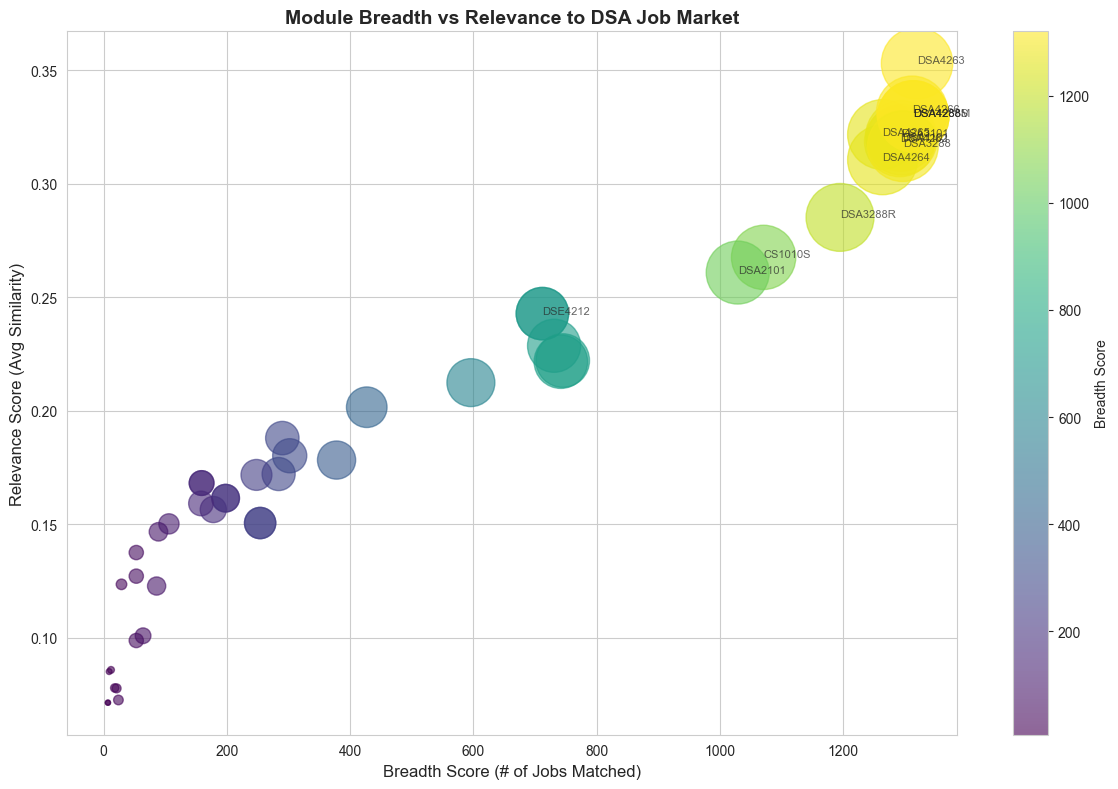

Saved: module_breadth_vs_relevance.png


In [ ]:
print("\n" + "="*80)
print("GENERATING MODULE VISUALIZATIONS")
print("="*80)

# 1. Scatter Plot: Breadth vs Relevance
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    module_analysis_df['breadth_score'], 
    module_analysis_df['relevance_score'],
    s=module_analysis_df['num_matching_jobs'] * 2,
    alpha=0.6,
    c=module_analysis_df['breadth_score'],
    cmap='viridis'
)

# Annotate top modules
top_modules_to_label = module_analysis_df.nlargest(15, 'relevance_score')
for idx, row in top_modules_to_label.iterrows():
    ax.annotate(
        row['module_code'], 
        (row['breadth_score'], row['relevance_score']),
        fontsize=8,
        alpha=0.7
    )

ax.set_xlabel('Breadth Score (# of Jobs Matched)', fontsize=12)
ax.set_ylabel('Relevance Score (Avg Similarity)', fontsize=12)
ax.set_title('Module Breadth vs Relevance to DSA Job Market', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Breadth Score')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'module_breadth_vs_relevance.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: module_breadth_vs_relevance.png")

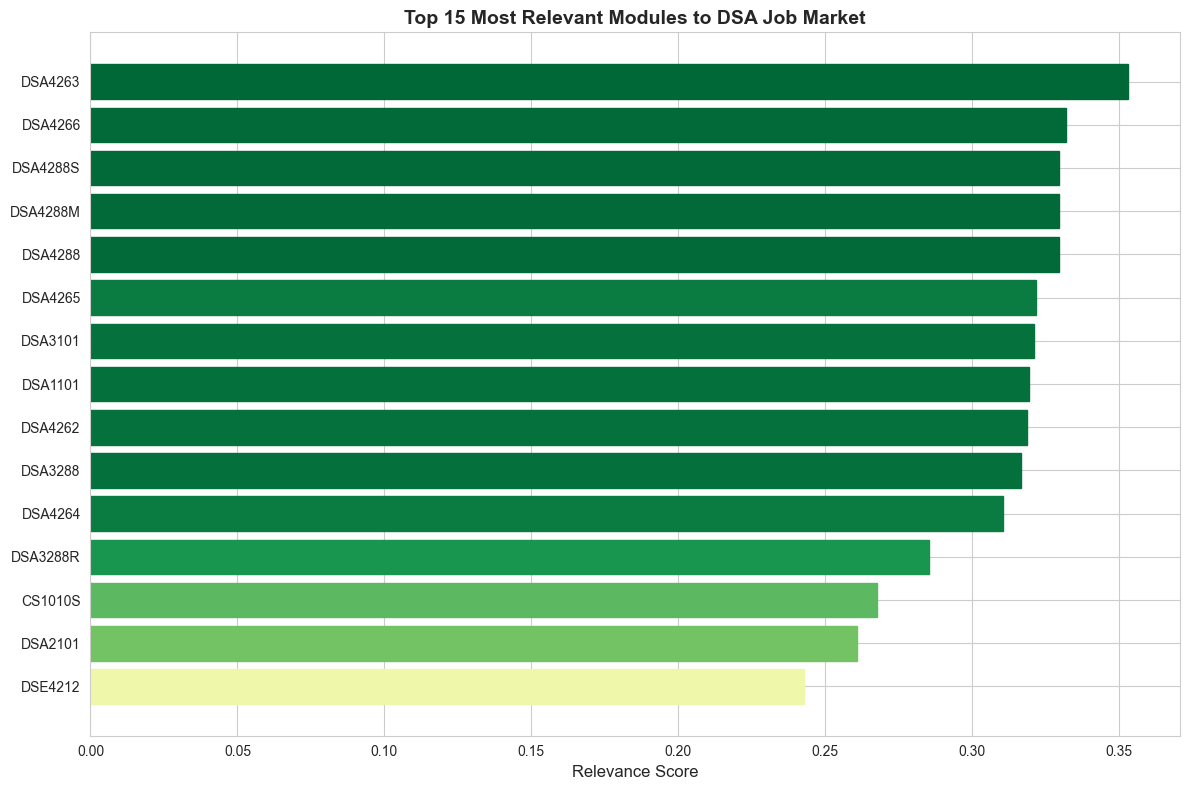

Saved: top_15_relevant_modules.png


In [ ]:
# 2. Top 15 Most Relevant Modules Bar Chart
fig, ax = plt.subplots(figsize=(12, 8))
top_15_relevant = module_analysis_df.nlargest(15, 'relevance_score').sort_values('relevance_score')
bars = ax.barh(range(len(top_15_relevant)), top_15_relevant['relevance_score'])
ax.set_yticks(range(len(top_15_relevant)))
ax.set_yticklabels(top_15_relevant['module_code'])
ax.set_xlabel('Relevance Score', fontsize=12)
ax.set_title('Top 15 Most Relevant Modules to DSA Job Market', fontsize=14, fontweight='bold')

# Color bars by breadth
colors = plt.cm.RdYlGn(top_15_relevant['breadth_score'] / top_15_relevant['breadth_score'].max())
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'top_15_relevant_modules.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: top_15_relevant_modules.png")

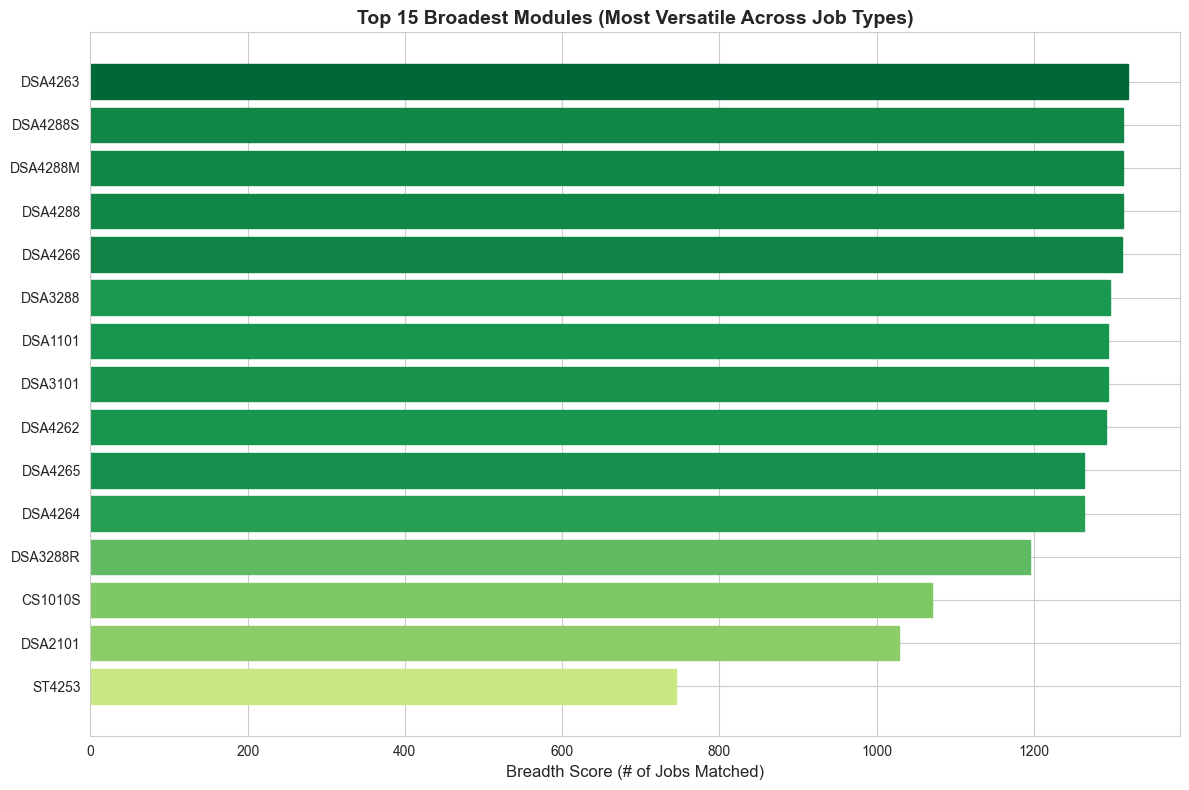

Saved: top_15_broadest_modules.png


In [ ]:
# 3. Top 15 Broadest Modules Bar Chart
fig, ax = plt.subplots(figsize=(12, 8))
top_15_broad = module_analysis_df.nlargest(15, 'breadth_score').sort_values('breadth_score')
bars = ax.barh(range(len(top_15_broad)), top_15_broad['breadth_score'])
ax.set_yticks(range(len(top_15_broad)))
ax.set_yticklabels(top_15_broad['module_code'])
ax.set_xlabel('Breadth Score (# of Jobs Matched)', fontsize=12)
ax.set_title('Top 15 Broadest Modules (Most Versatile Across Job Types)', fontsize=14, fontweight='bold')

# Color bars by relevance
colors = plt.cm.RdYlGn(top_15_broad['relevance_score'] / top_15_broad['relevance_score'].max())
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'top_15_broadest_modules.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: top_15_broadest_modules.png")

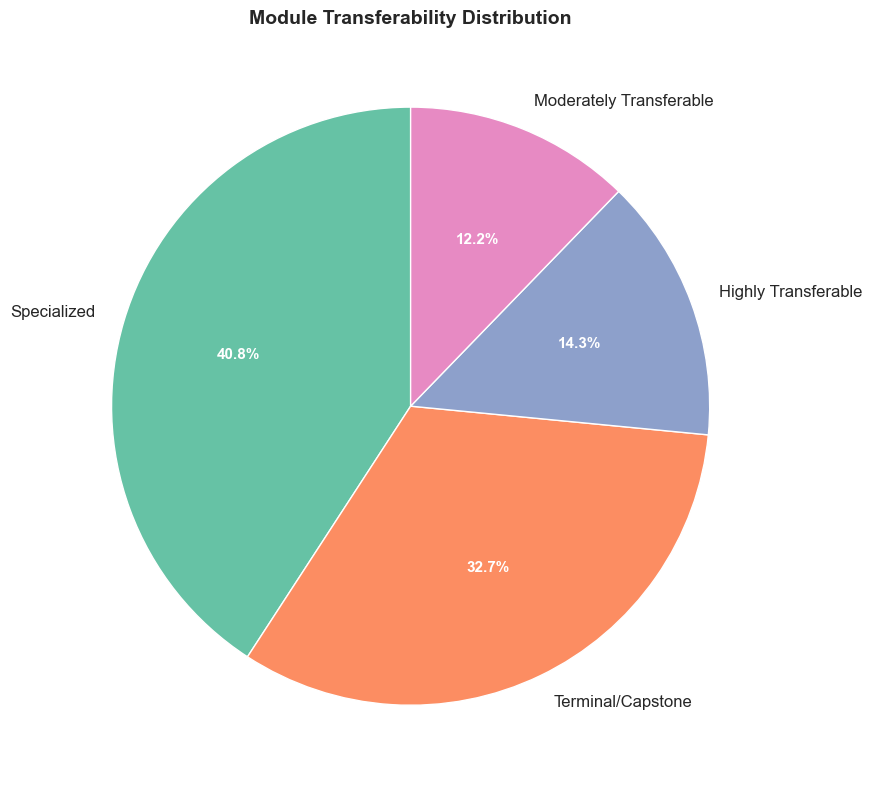

Saved: transferability_distribution.png


In [ ]:
# 4. Transferability Distribution Pie Chart
fig, ax = plt.subplots(figsize=(10, 8))
transferability_counts = module_analysis_df['transferability_category'].value_counts()
colors_pie = sns.color_palette("Set2", len(transferability_counts))
wedges, texts, autotexts = ax.pie(
    transferability_counts.values, 
    labels=transferability_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_pie
)
for text in texts:
    text.set_fontsize(12)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
ax.set_title('Module Transferability Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'transferability_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: transferability_distribution.png")

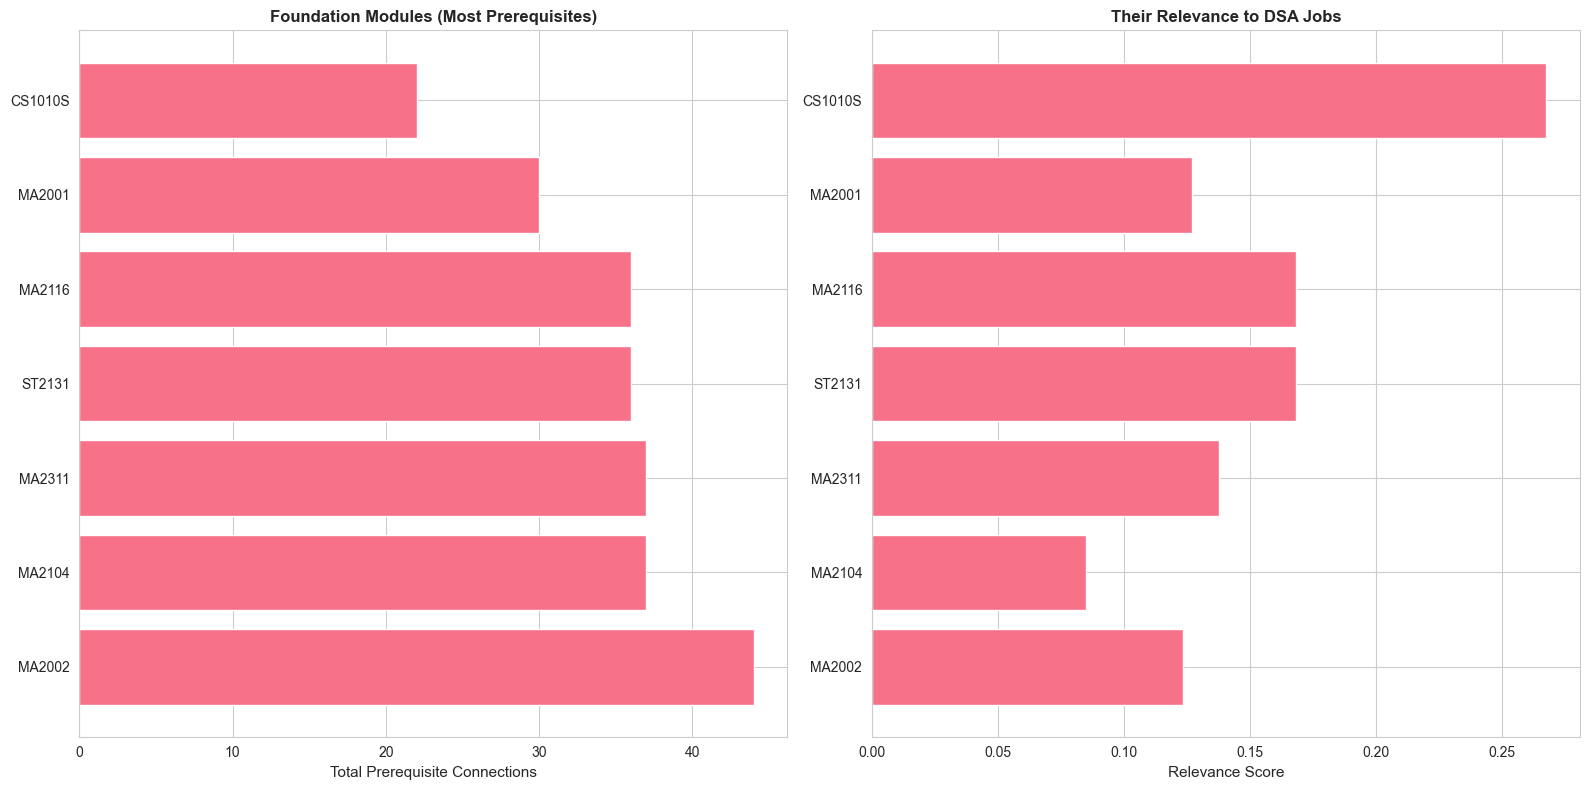

Saved: foundation_modules_analysis.png


In [ ]:
# 6. Foundation Modules Analysis (dual bar chart)
highly_transferable_df = module_analysis_df[
    module_analysis_df['transferability_category'] == 'Highly Transferable'
].sort_values('total', ascending=False).head(15)

if len(highly_transferable_df) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Left: Prerequisite counts
    bars1 = ax1.barh(range(len(highly_transferable_df)), highly_transferable_df['total'])
    ax1.set_yticks(range(len(highly_transferable_df)))
    ax1.set_yticklabels(highly_transferable_df['module_code'])
    ax1.set_xlabel('Total Prerequisite Connections', fontsize=11)
    ax1.set_title('Foundation Modules (Most Prerequisites)', fontsize=12, fontweight='bold')
    
    # Right: Relevance scores
    bars2 = ax2.barh(range(len(highly_transferable_df)), highly_transferable_df['relevance_score'])
    ax2.set_yticks(range(len(highly_transferable_df)))
    ax2.set_yticklabels(highly_transferable_df['module_code'])
    ax2.set_xlabel('Relevance Score', fontsize=11)
    ax2.set_title('Their Relevance to DSA Jobs', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, 'foundation_modules_analysis.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: foundation_modules_analysis.png")
else:
    print("No highly transferable modules found")

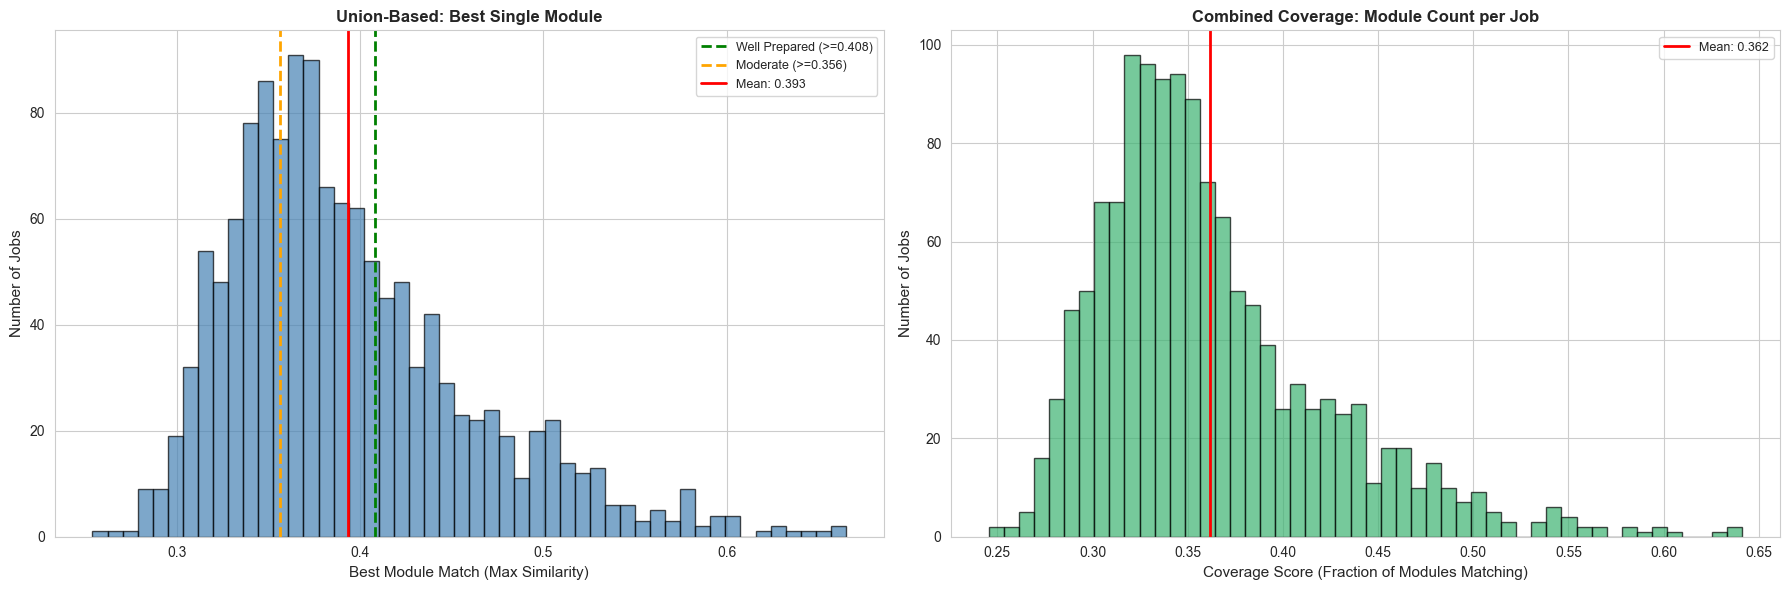

Saved: degree_preparation_distribution.png


In [ ]:
# 7. Degree Preparation Distribution Histogram (Dual Analysis)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Left: Union-based (Best Single Module)
union_well = np.percentile(max_similarities_per_job, 67)
union_mod = np.percentile(max_similarities_per_job, 33)

ax1.hist(max_similarities_per_job, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(union_well, color='green', linestyle='--', linewidth=2, label=f'Well Prepared (>={union_well:.3f})')
ax1.axvline(union_mod, color='orange', linestyle='--', linewidth=2, label=f'Moderate (>={union_mod:.3f})')
ax1.axvline(union_relevance, color='red', linestyle='-', linewidth=2, label=f'Mean: {union_relevance:.3f}')
ax1.set_xlabel('Best Module Match (Max Similarity)', fontsize=11)
ax1.set_ylabel('Number of Jobs', fontsize=11)
ax1.set_title('Union-Based: Best Single Module', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)

# Right: Combined Coverage (Module Count per Job)
ax2.hist(collective_score_per_job, bins=50, edgecolor='black', alpha=0.7, color='mediumseagreen')
ax2.axvline(combined_relevance, color='red', linestyle='-', linewidth=2, label=f'Mean: {combined_relevance:.3f}')
ax2.set_xlabel('Coverage Score (Fraction of Modules Matching)', fontsize=11)
ax2.set_ylabel('Number of Jobs', fontsize=11)
ax2.set_title('Combined Coverage: Module Count per Job', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'degree_preparation_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: degree_preparation_distribution.png")

---
# PART 6: Save Results

In [ ]:
print("\n" + "="*80)
print("SAVING RESULTS & AGGREGATED SUMMARY")
print("="*80)

# Save module analysis
module_analysis_output = os.path.join(MODULE_ANALYSIS_DIR, "module_analysis_results.csv")
module_analysis_df.to_csv(module_analysis_output, index=False)
print(f"Saved module analysis to {module_analysis_output}")

# Save DSA jobs
jobs_output = os.path.join(MODULE_ANALYSIS_DIR, "relevant_jobs.csv")
save_columns = ['title', 'description', 'semantic_avg_similarity', 'skill_votes', 'skill_coverage']
if 'companyName' in dsa_jobs_df.columns:
    save_columns.insert(1, 'companyName')
elif 'company' in dsa_jobs_df.columns:
    save_columns.insert(1, 'company')
dsa_jobs_df[save_columns].to_csv(jobs_output, index=False)
print(f"Saved relevant jobs to {jobs_output}")

# Save top 100 job matches
top_jobs_output = os.path.join(MODULE_ANALYSIS_DIR, "top_100_job_matches.csv")
cols_to_save = ["title", "skill_votes", "skill_coverage", "semantic_avg_similarity", "best_matching_module", "description"]
if 'companyName' in jobs_df.columns:
    cols_to_save.insert(1, 'companyName')
elif 'company' in jobs_df.columns:
    cols_to_save.insert(1, 'company')
top_100 = jobs_df.nlargest(100, 'skill_votes')[cols_to_save]
top_100.to_csv(top_jobs_output, index=False)
print(f"Saved top 100 job matches to {top_jobs_output}")

# ============================================
# AGGREGATED DEGREE SUMMARY
# ============================================
degree_summary = {
    'degree': TARGET_DEGREE,
    'school': 'nus',
    'total_modules': len(modules_df),
    'total_jobs_scanned': len(jobs_df),
    'market_size': len(dsa_jobs_df),
    'market_cutoff_score': final_cutoff,
    'union_relevance': union_relevance,
    'collective_relevance': combined_relevance,
    'active_core_utilization_pct': degree_utilization,
    'supporting_skill_breadth_pct': niche_utilization,
    'well_prepared_jobs': well_prepared_jobs,
    'well_prepared_pct': (well_prepared_jobs / len(dsa_jobs_df)) * 100,
    'moderately_prepared_jobs': moderately_prepared_jobs,
    'moderately_prepared_pct': (moderately_prepared_jobs / len(dsa_jobs_df)) * 100,
    'underprepared_jobs': underprepared_jobs,
    'underprepared_pct': (underprepared_jobs / len(dsa_jobs_df)) * 100,
    'top_module': module_analysis_df.nlargest(1, 'relevance_score').iloc[0]['module_code'],
    'top_module_relevance': module_analysis_df['relevance_score'].max(),
    'avg_module_relevance': module_analysis_df['relevance_score'].mean(),
}

summary_df = pd.DataFrame([degree_summary])
summary_output = os.path.join(MODULE_ANALYSIS_DIR, "degree_summary.csv")
summary_df.to_csv(summary_output, index=False)
print(f"\nSaved aggregated summary to {summary_output}")

print("\n" + "="*80)
print("DEGREE SUMMARY METRICS")
print("="*80)
print(f"Degree:                        {TARGET_DEGREE}")
print(f"Total Modules:                 {len(modules_df)}")
print(f"Total Jobs Scanned:            {len(jobs_df):,}")
print(f"Market Size (Filtered):        {len(dsa_jobs_df):,}")
print(f"Market Cutoff Score:           {final_cutoff:.4f}")
print(f"\nRelevance Metrics:")
print(f"  Union Relevance:             {union_relevance:.3f}")
print(f"  Collective Relevance:        {combined_relevance:.3f}")
print(f"  Active Core Utilization:     {degree_utilization:.1f}%")
print(f"  Supporting Skill Breadth:    {niche_utilization:.1f}%")
print(f"\nJob Preparation Coverage:")
print(f"  Well Prepared:               {well_prepared_jobs} ({(well_prepared_jobs/len(dsa_jobs_df))*100:.1f}%)")
print(f"  Moderately Prepared:         {moderately_prepared_jobs} ({(moderately_prepared_jobs/len(dsa_jobs_df))*100:.1f}%)")
print(f"  Under-prepared:              {underprepared_jobs} ({(underprepared_jobs/len(dsa_jobs_df))*100:.1f}%)")
print(f"\nTop Module:")
print(f"  {module_analysis_df.nlargest(1, 'relevance_score').iloc[0]['module_code']}: {module_analysis_df['relevance_score'].max():.3f}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print(f"\nGenerated outputs:")
print(f"  - Global visualizations:     {GLOBAL_OUTPUT_DIR}")
print(f"  - Degree analysis:           {MODULE_ANALYSIS_DIR}")
print(f"  - Visualizations:            {VIZ_DIR}")
print(f"  - 8 PNG visualizations saved")
print(f"  - Aggregated summary:        degree_summary.csv")


SAVING RESULTS & AGGREGATED SUMMARY
Saved module analysis to ../outputs/analysis_results/nus/data_sci_analytics/module_analysis_results.csv
Saved relevant jobs to ../outputs/analysis_results/nus/data_sci_analytics/relevant_jobs.csv
Saved top 100 job matches to ../outputs/analysis_results/nus/data_sci_analytics/top_100_job_matches.csv

Saved aggregated summary to ../outputs/analysis_results/nus/data_sci_analytics/degree_summary.csv

DEGREE SUMMARY METRICS
Degree:                        data_sci_analytics
Total Modules:                 49
Total Jobs Scanned:            16,686
Market Size (Filtered):        1,323
Market Cutoff Score:           0.1696

Relevance Metrics:
  Union Relevance:             0.393
  Collective Relevance:        0.362
  Active Core Utilization:     49.0%
  Supporting Skill Breadth:    63.3%

Job Preparation Coverage:
  Well Prepared:               286 (21.6%)
  Moderately Prepared:         896 (67.7%)
  Under-prepared:              141 (10.7%)

Top Module:
  DSA4

---
# PART 7: Multi-School Batch Analysis
Run the same analysis for all 21 degrees across NUS, SMU, SUTD

# Import utilities for multi-school analysis
import sys
sys.path.append('..')
import config
import analysis_utils as au
from tqdm import tqdm

print("Loaded multi-school utilities")

In [ ]:
# Configuration for batch mode
import sys
sys.path.append('..')
import config
import analysis_utils as au
from tqdm import tqdm

# Which degrees to generate detailed visualizations for?
VIZ_MODE = 'top_n'  # Options: 'top_n', 'representative', 'manual', 'none'
TOP_N = 10          # If using 'top_n' mode

# For 'manual' mode:
# MANUAL_VIZ_DEGREES = [('nus', 'data_sci_analytics'), ('smu', 'business')]

print("Multi-school batch configuration loaded")
print(f"Visualization mode: {VIZ_MODE}")
if VIZ_MODE == 'top_n':
    print(f"Will visualize top {TOP_N} degrees")

Multi-school batch configuration loaded
Visualization mode: top_n
Will visualize top 10 degrees


## Batch: Analyze All Remaining Degrees

This section analyzes all 21 degrees (reusing the job data already loaded above)

In [ ]:
print("\n" + "="*80)
print("BATCH ANALYSIS: ALL DEGREES")
print("="*80)

all_degrees = config.get_all_degrees()
print(f"Will analyze {len(all_degrees)} degrees total")

all_results = []
failed_degrees = []
all_collective_scores = []

filtered_jobs_batch = jobs_df.copy()
job_embeddings_batch = all_job_embeddings

print(f"Reusing {len(filtered_jobs_batch):,} jobs already loaded\n")

# ============================================
# PASS 1: Collect global statistics
# ============================================
print("PASS 1: Collecting global statistics...")
for school, degree in tqdm(all_degrees, desc="Processing all degrees"):
    try:
        full_name = config.get_degree_full_name(school, degree)
        
        modules_df_batch = au.load_degree_modules(school, degree, config)
        if len(modules_df_batch) == 0:
            failed_degrees.append((school, degree, "No modules"))
            continue
        
        module_embeddings_batch = au.extract_embeddings(modules_df_batch)
        
        similarity_matrix_batch, votes, avg_sim = au.calculate_approval_voting(
            module_embeddings_batch,
            job_embeddings_batch,
            threshold=0.5
        )
        
        filtered_jobs_batch['_temp_sim'] = avg_sim
        relevant_jobs_batch, cutoff_idx, cutoff_score = au.find_relevant_job_market(
            filtered_jobs_batch,
            avg_sim,
            method='kneedle'
        )
        
        metrics_batch = au.calculate_degree_metrics(
            modules_df_batch,
            relevant_jobs_batch,
            similarity_matrix_batch
        )
        
        collective_scores_batch = metrics_batch.get('collective_score_per_job', [])
        if len(collective_scores_batch) > 0:
            all_collective_scores.extend(collective_scores_batch.tolist())
        
        all_results.append({
            'school': school,
            'degree': degree,
            'full_name': full_name,
            'modules_df': modules_df_batch,
            'relevant_jobs': relevant_jobs_batch,
            'similarity_matrix': similarity_matrix_batch,
            'metrics': metrics_batch,
            'cutoff_score': cutoff_score,
        })
        
    except Exception as e:
        print(f"  [ERROR] {school}/{degree}: {e}")
        failed_degrees.append((school, degree, str(e)))

# ============================================
# Calculate global thresholds
# ============================================
print(f"\n{'='*80}")
print("GLOBAL THRESHOLD CALCULATION")
print(f"{'='*80}")

global_mean = np.mean(all_collective_scores)
global_std = np.std(all_collective_scores)

well_prepared_threshold_global = global_mean + 0.5 * global_std
moderate_threshold_global = global_mean - 0.5 * global_std

print(f"Total collective scores collected: {len(all_collective_scores):,}")
print(f"Global mean collective relevance:  {global_mean:.4f}")
print(f"Global std deviation:              {global_std:.4f}")
print(f"\nGlobal Thresholds:")
print(f"  Well Prepared:     ≥ {well_prepared_threshold_global:.4f}  (mean + 0.5σ)")
print(f"  Moderately Prepared: {moderate_threshold_global:.4f} - {well_prepared_threshold_global:.4f}")
print(f"  Under-prepared:    < {moderate_threshold_global:.4f}  (mean - 0.5σ)")

global_stats = {
    'global_mean_collective': global_mean,
    'global_std_collective': global_std,
    'well_prepared_threshold': well_prepared_threshold_global,
    'moderate_threshold': moderate_threshold_global,
    'total_scores_analyzed': len(all_collective_scores),
    'num_degrees': len(all_results)
}
global_stats_df = pd.DataFrame([global_stats])
global_stats_output = config.SUMMARY_OUTPUT_DIR / "global_thresholds.csv"
global_stats_df.to_csv(global_stats_output, index=False)
print(f"\nSaved global stats to: {global_stats_output}")

# ============================================
# PASS 2: Apply global thresholds
# ============================================
print(f"\n{'='*80}")
print("PASS 2: Applying global thresholds to all degrees")
print(f"{'='*80}\n")

final_results = []
for result in tqdm(all_results, desc="Finalizing degrees"):
    school = result['school']
    degree = result['degree']
    full_name = result['full_name']
    modules_df_batch = result['modules_df']
    relevant_jobs_batch = result['relevant_jobs']
    similarity_matrix_batch = result['similarity_matrix']
    metrics_batch = result['metrics']
    cutoff_score = result['cutoff_score']
    
    collective_score_per_job_batch = metrics_batch.get('collective_score_per_job', np.array([]))
    
    well_prepared_jobs_batch = (collective_score_per_job_batch >= well_prepared_threshold_global).sum()
    moderately_prepared_jobs_batch = (
        (collective_score_per_job_batch >= moderate_threshold_global) & 
        (collective_score_per_job_batch < well_prepared_threshold_global)
    ).sum()
    underprepared_jobs_batch = len(collective_score_per_job_batch) - well_prepared_jobs_batch - moderately_prepared_jobs_batch
    
    module_analysis_batch = au.analyze_modules(
        modules_df_batch,
        relevant_jobs_batch,
        similarity_matrix_batch,
        breadth_percentile=60
    )
    
    degree_output_dir = config.get_degree_output_dir(school, degree)
    module_analysis_batch.to_csv(degree_output_dir / "module_analysis_results.csv", index=False)
    relevant_jobs_batch[['title', 'description', '_temp_sim']].rename(
        columns={'_temp_sim': 'avg_similarity'}
    ).to_csv(degree_output_dir / "relevant_jobs.csv", index=False)
    
    degree_summary_batch = {
        'school': school,
        'degree': degree,
        'degree_full_name': full_name,
        'category': config.DEGREES[school]['degrees'][degree]['category'],
        'total_modules': len(modules_df_batch),
        'market_size': len(relevant_jobs_batch),
        'market_cutoff_score': cutoff_score,
        'union_relevance': metrics_batch['union_relevance'],
        'collective_relevance': metrics_batch['collective_relevance'],
        'well_prepared_jobs': well_prepared_jobs_batch,
        'well_prepared_pct': (well_prepared_jobs_batch / len(relevant_jobs_batch)) * 100 if len(relevant_jobs_batch) > 0 else 0,
        'moderately_prepared_jobs': moderately_prepared_jobs_batch,
        'moderately_prepared_pct': (moderately_prepared_jobs_batch / len(relevant_jobs_batch)) * 100 if len(relevant_jobs_batch) > 0 else 0,
        'underprepared_jobs': underprepared_jobs_batch,
        'underprepared_pct': (underprepared_jobs_batch / len(relevant_jobs_batch)) * 100 if len(relevant_jobs_batch) > 0 else 0,
        'top_module': module_analysis_batch.nlargest(1, 'relevance_score').iloc[0]['module_code'],
        'top_module_relevance': module_analysis_batch['relevance_score'].max(),
    }
    
    pd.DataFrame([degree_summary_batch]).to_csv(
        degree_output_dir / "degree_summary.csv", index=False
    )
    
    final_results.append(degree_summary_batch)
    
    print(f"{full_name:70s} | Well: {well_prepared_jobs_batch:4d} ({degree_summary_batch['well_prepared_pct']:5.1f}%)")

print("\n" + "="*80)
print(f"BATCH COMPLETE: {len(final_results)}/{len(all_degrees)} degrees")
print("="*80)

all_results = final_results


BATCH ANALYSIS: ALL DEGREES
Will analyze 21 degrees total
Reusing 16,686 jobs already loaded

PASS 1: Collecting global statistics...


Processing all degrees: 100%|██████████| 21/21 [00:01<00:00, 13.44it/s]



GLOBAL THRESHOLD CALCULATION
Total collective scores collected: 37,016
Global mean collective relevance:  0.2759
Global std deviation:              0.0815

Global Thresholds:
  Well Prepared:     ≥ 0.3166  (mean + 0.5σ)
  Moderately Prepared: 0.2352 - 0.3166
  Under-prepared:    < 0.2352  (mean - 0.5σ)

Saved global stats to: /Users/teresaliau/dsa4264/notebooks/../outputs/summary/global_thresholds.csv

PASS 2: Applying global thresholds to all degrees



Finalizing degrees:  10%|▉         | 2/21 [00:00<00:01, 14.21it/s]

National University of Singapore - Data Science and Analytics          | Well:  117 (  8.3%)
National University of Singapore - Business Analytics                  | Well:  784 ( 44.2%)


...

Singapore Management University - Computing and Law                    | Well:  207 ( 17.5%)
Singapore Management University - Economics                            | Well:  318 ( 20.7%)
Singapore Management University - Information Systems                  | Well:  177 ( 10.3%)


Finalizing degrees:  86%|████████▌ | 18/21 [00:00<00:00, 27.53it/s]

Singapore Management University - Social Sciences                      | Well:  441 ( 35.4%)
Singapore University of Technology and Design - Architecture and Sustainable Design | Well:  595 ( 22.5%)
Singapore University of Technology and Design - Computer Science and Design | Well:  176 (  8.5%)


Finalizing degrees: 100%|██████████| 21/21 [00:00<00:00, 25.77it/s]

Singapore University of Technology and Design - Design and AI          | Well:  203 ( 12.3%)
Singapore University of Technology and Design - Engineering Product Development | Well:  433 ( 23.7%)
Singapore University of Technology and Design - Engineering Systems and Design | Well:  440 ( 33.0%)

BATCH COMPLETE: 21/21 degrees


## Aggregated Comparison Table

In [ ]:
comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df.sort_values('union_relevance', ascending=False)

print("\n" + "="*80)
print("AGGREGATED COMPARISON: ALL DEGREES")
print("="*80)
print(comparison_df[[
    'school', 'degree_full_name', 'total_modules', 'market_size', 
    'union_relevance', 'collective_relevance', 'well_prepared_pct'
]].to_string(index=False))

# Save
config.SUMMARY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
comparison_output = config.SUMMARY_OUTPUT_DIR / "all_degrees_comparison.csv"
comparison_df.to_csv(comparison_output, index=False)
print(f"\nSaved to: {comparison_output}")

# Key insights
print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

print("\nTOP 5 BY UNION RELEVANCE:")
for _, row in comparison_df.nlargest(5, 'union_relevance').iterrows():
    print(f"  {row['degree_full_name']:60s}: {row['union_relevance']:.3f} (well prep: {row['well_prepared_pct']:5.1f}%)")

print("\nTOP 5 BY WELL-PREPARED PERCENTAGE:")
for _, row in comparison_df.nlargest(5, 'well_prepared_pct').iterrows():
    print(f"  {row['degree_full_name']:60s}: {row['well_prepared_pct']:5.1f}% ({row['well_prepared_jobs']} jobs)")

print("\nBOTTOM 5 BY WELL-PREPARED PERCENTAGE:")
for _, row in comparison_df.nsmallest(5, 'well_prepared_pct').iterrows():
    print(f"  {row['degree_full_name']:60s}: {row['well_prepared_pct']:5.1f}% ({row['well_prepared_jobs']} jobs)")

print("\nSCHOOL AVERAGES:")
school_avg = comparison_df.groupby('school').agg({
    'market_size': 'mean',
    'union_relevance': 'mean',
    'collective_relevance': 'mean',
    'well_prepared_pct': 'mean'
}).round(3)
print(school_avg)

print("\nPREPARATION DISTRIBUTION SUMMARY:")
print(f"Average Well Prepared:       {comparison_df['well_prepared_pct'].mean():.1f}%")
print(f"Average Moderately Prepared: {comparison_df['moderately_prepared_pct'].mean():.1f}%")
print(f"Average Under-prepared:      {comparison_df['underprepared_pct'].mean():.1f}%")

if failed_degrees:
    print(f"\nFailed: {len(failed_degrees)} degrees")
    for s, d, err in failed_degrees:
        print(f"  {s}/{d}: {err}")


AGGREGATED COMPARISON: ALL DEGREES
school                                                                    degree_full_name  total_modules  market_size  union_relevance  collective_relevance  well_prepared_pct
   smu                                          Singapore Management University - Business             29         1085         0.385682              0.334958          55.576037
   nus                               National University of Singapore - Business Analytics             52         1772         0.375930              0.309011          44.243792
   nus                              National University of Singapore - Information Systems             50         1984         0.372831              0.322472          51.209677
   smu                                       Singapore Management University - Accountancy             68         1805         0.367946              0.333027          51.689751
   nus                                      National University of Singapore - 

# Additional Insights & Visualizations

This section provides cross-degree comparisons and highlights interesting patterns from the batch analysis.

In [ ]:
# Load comparison data for additional analysis
comparison_file = config.SUMMARY_OUTPUT_DIR / "all_degrees_comparison.csv"
comparison_data = pd.read_csv(comparison_file)
global_thresholds_file = config.SUMMARY_OUTPUT_DIR / "global_thresholds.csv"
global_thresholds = pd.read_csv(global_thresholds_file)

## Top vs Bottom Performers

Comparison of best and worst performing degrees

In [ ]:
#  Top 5 vs Bottom 5 comparison
import textwrap

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Top 5
top5 = comparison_data.nlargest(5, 'well_prepared_pct')
# Wrap full degree name (including school)
top5_labels = ['\n'.join(textwrap.wrap(name, 35)) for name in top5['degree_full_name']]

ax1.barh(range(len(top5)), top5['well_prepared_pct'], color='green', alpha=0.7)
ax1.set_yticks(range(len(top5)))
ax1.set_yticklabels(top5_labels, fontsize=11)
ax1.set_xlabel('Well Prepared %', fontsize=12)
ax1.set_title('Top 5 Degrees by Preparation Quality', fontsize=14, fontweight='bold')
ax1.axvline(global_thresholds.iloc[0]['well_prepared_threshold']*100, color='red', linestyle='--', label='Global Threshold')
for i, (idx, row) in enumerate(top5.iterrows()):
    ax1.text(row['well_prepared_pct'] + 1, i, f"{row['well_prepared_pct']:.1f}%", va='center', fontsize=10)
ax1.legend()

# Bottom 5
bottom5 = comparison_data.nsmallest(5, 'well_prepared_pct').sort_values('well_prepared_pct')
# Wrap full degree name (including school)
bottom5_labels = ['\n'.join(textwrap.wrap(name, 35)) for name in bottom5['degree_full_name']]

ax2.barh(range(len(bottom5)), bottom5['well_prepared_pct'], color='red', alpha=0.7)
ax2.set_yticks(range(len(bottom5)))
ax2.set_yticklabels(bottom5_labels, fontsize=11)
ax2.set_xlabel('Well Prepared %', fontsize=12)
ax2.set_title('Bottom 5 Degrees by Preparation Quality', fontsize=14, fontweight='bold')
ax2.axvline(global_thresholds.iloc[0]['well_prepared_threshold']*100, color='red', linestyle='--', label='Global Threshold')
for i, (idx, row) in enumerate(bottom5.iterrows()):
    ax2.text(row['well_prepared_pct'] + 0.5, i, f"{row['well_prepared_pct']:.1f}%", va='center', fontsize=10)
ax2.legend()

plt.tight_layout()
plt.savefig(config.SUMMARY_OUTPUT_DIR / 'top5_vs_bottom5_degrees.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: top5_vs_bottom5_degrees.png")

## School-Level Comparison

How do NUS, SMU, and SUTD compare overall?

/var/folders/wc/5cwlt66x6d12kf_tz4qkd_580000gn/T/ipykernel_73530/588438205.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot(school_prep_data, labels=[s.upper() for s in schools], patch_artist=True)


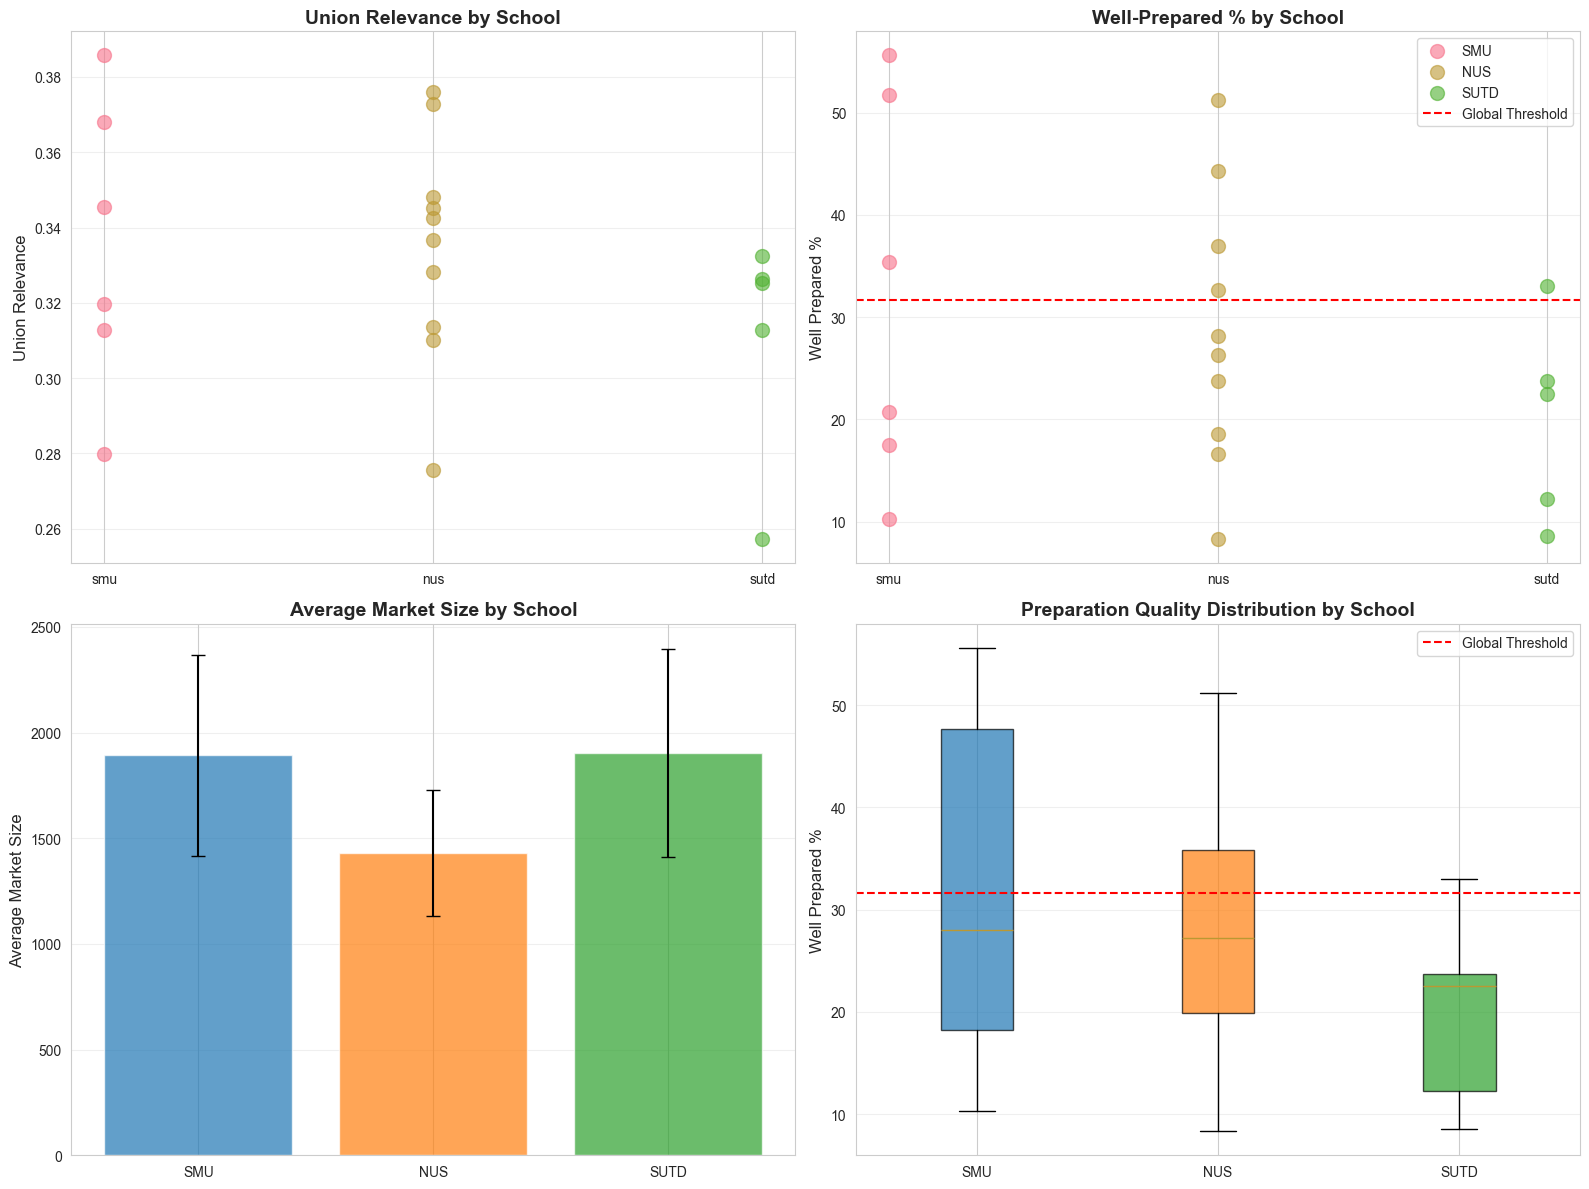

In [ ]:
# School comparison
school_stats = comparison_data.groupby('school').agg({
    'union_relevance': ['mean', 'std'],
    'collective_relevance': ['mean', 'std'],
    'well_prepared_pct': ['mean', 'std'],
    'market_size': 'mean'
}).round(3)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Union Relevance by School
schools = comparison_data['school'].unique()
for school in schools:
    school_data = comparison_data[comparison_data['school'] == school]
    axes[0, 0].scatter([school] * len(school_data), school_data['union_relevance'], 
                      s=100, alpha=0.6, label=school.upper())
axes[0, 0].set_ylabel('Union Relevance', fontsize=12)
axes[0, 0].set_title('Union Relevance by School', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Well Prepared % by School  
for school in schools:
    school_data = comparison_data[comparison_data['school'] == school]
    axes[0, 1].scatter([school] * len(school_data), school_data['well_prepared_pct'],
                      s=100, alpha=0.6, label=school.upper())
axes[0, 1].axhline(global_thresholds.iloc[0]['well_prepared_threshold']*100, 
                   color='red', linestyle='--', label='Global Threshold')
axes[0, 1].set_ylabel('Well Prepared %', fontsize=12)
axes[0, 1].set_title('Well-Prepared % by School', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].legend()

# Plot 3: Market Size by School
school_market_data = comparison_data.groupby('school')['market_size'].agg(['mean', 'std', 'min', 'max'])
x_pos = range(len(schools))
axes[1, 0].bar(x_pos, school_market_data['mean'], yerr=school_market_data['std'],
              alpha=0.7, capsize=5, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels([s.upper() for s in schools])
axes[1, 0].set_ylabel('Average Market Size', fontsize=12)
axes[1, 0].set_title('Average Market Size by School', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Box plot of preparation quality
school_prep_data = [comparison_data[comparison_data['school'] == school]['well_prepared_pct'].values 
                    for school in schools]
bp = axes[1, 1].boxplot(school_prep_data, labels=[s.upper() for s in schools], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#1f77b4', '#ff7f0e', '#2ca02c']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].axhline(global_thresholds.iloc[0]['well_prepared_threshold']*100,
                   color='red', linestyle='--', label='Global Threshold')
axes[1, 1].set_ylabel('Well Prepared %', fontsize=12)
axes[1, 1].set_title('Preparation Quality Distribution by School', fontsize=14, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Market Size vs Preparation Quality

Does a larger job market mean better preparation? Let's find out.

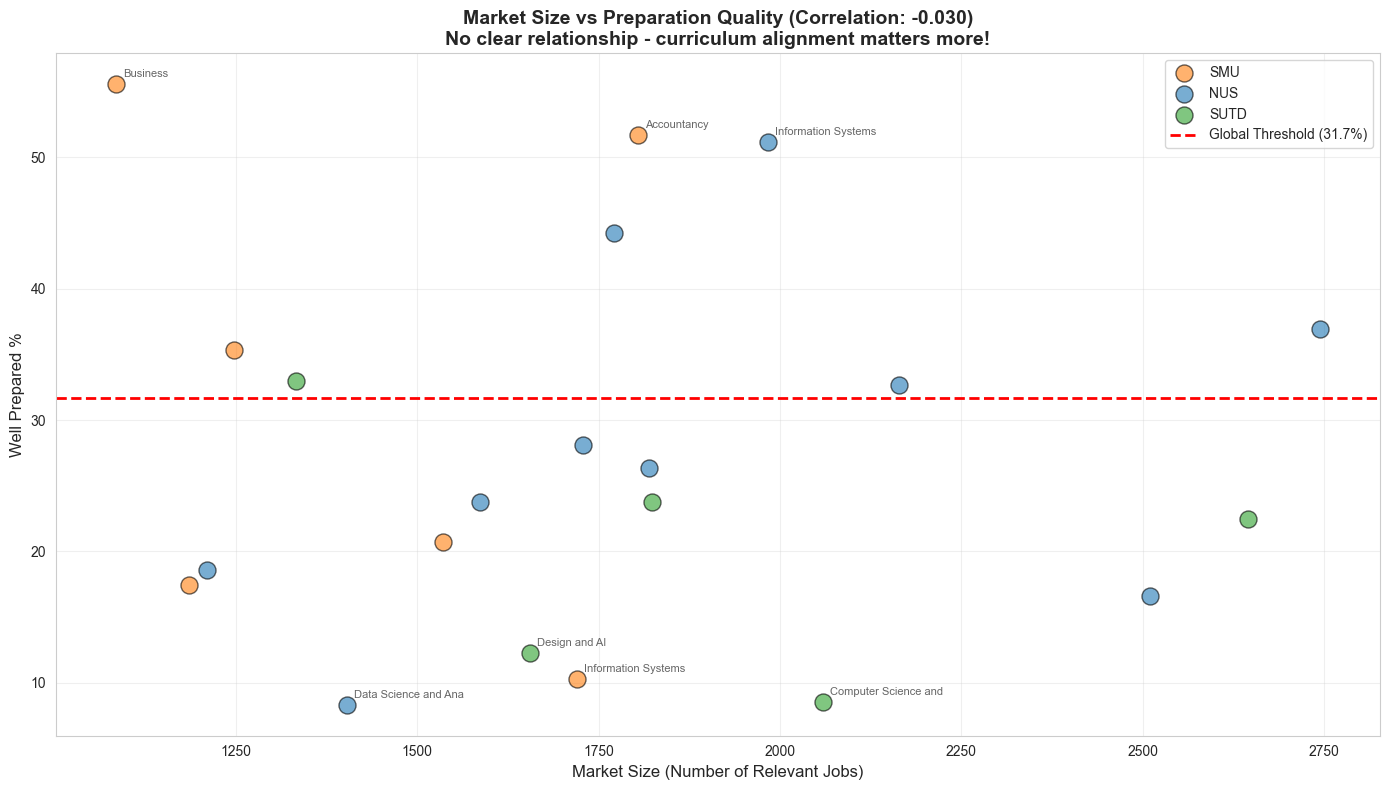

In [ ]:
# Market Size vs Preparation Quality Scatter
fig, ax = plt.subplots(figsize=(14, 8))

# Color by school
colors = {'nus': '#1f77b4', 'smu': '#ff7f0e', 'sutd': '#2ca02c'}
for school in comparison_data['school'].unique():
    school_data = comparison_data[comparison_data['school'] == school]
    ax.scatter(school_data['market_size'], school_data['well_prepared_pct'],
              s=150, alpha=0.6, c=colors[school], label=school.upper(), edgecolors='black')

# Add labels for notable degrees
for idx, row in comparison_data.iterrows():
    if row['well_prepared_pct'] > 45 or row['well_prepared_pct'] < 15:
        ax.annotate(row['degree_full_name'].split(' - ')[-1][:20], 
                   (row['market_size'], row['well_prepared_pct']),
                   fontsize=8, alpha=0.7, xytext=(5, 5), textcoords='offset points')

ax.axhline(global_thresholds.iloc[0]['well_prepared_threshold']*100,
          color='red', linestyle='--', linewidth=2, label=f"Global Threshold ({global_thresholds.iloc[0]['well_prepared_threshold']*100:.1f}%)")
ax.set_xlabel('Market Size (Number of Relevant Jobs)', fontsize=12)
ax.set_ylabel('Well Prepared %', fontsize=12)

# Calculate and show correlation in title
correlation = comparison_data['market_size'].corr(comparison_data['well_prepared_pct'])
ax.set_title(f'Market Size vs Preparation Quality (Correlation: {correlation:.3f})\nNo clear relationship - curriculum alignment matters more!', 
            fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Category-Level Patterns

How do different degree categories (Business, Data Science, Engineering, etc.) compare?

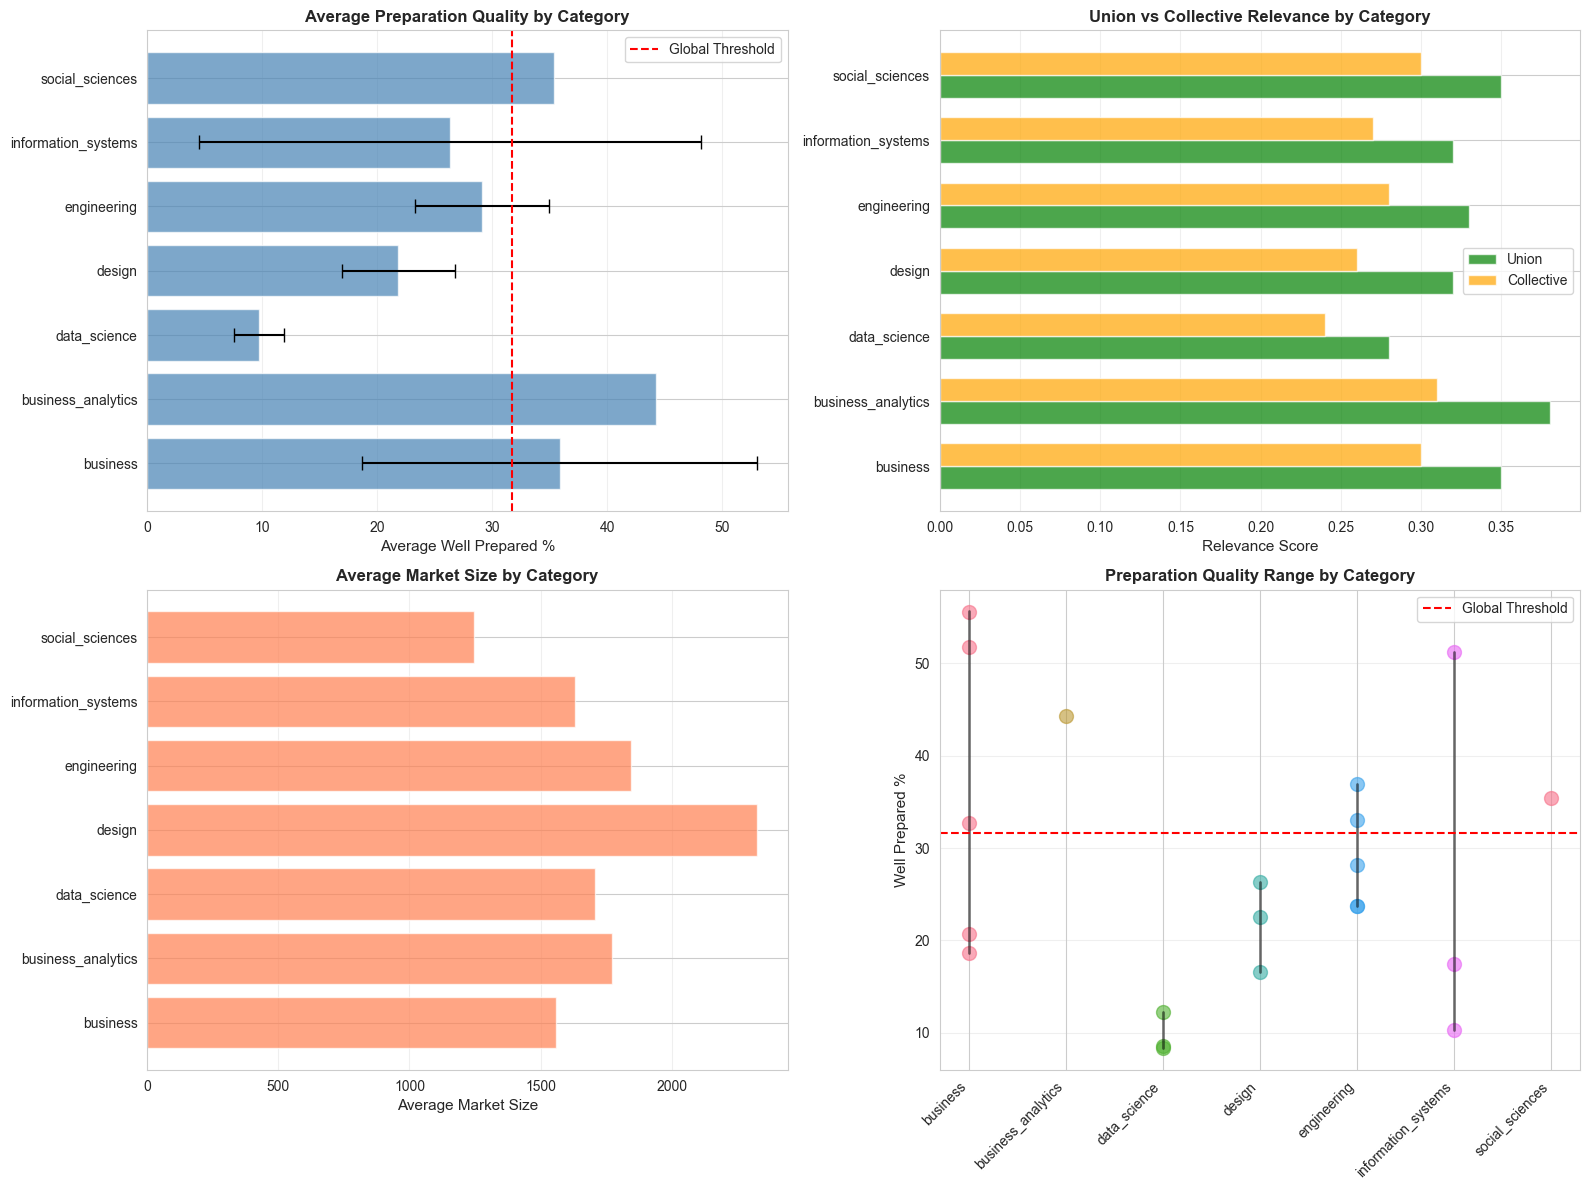

,category,well_prepared_pct_mean,well_prepared_pct_std,well_prepared_pct_min,well_prepared_pct_max,union_relevance_mean,collective_relevance_mean,market_size_mean
0,business,35.85,17.15,18.60,55.58,0.35,0.30,1559.8
1,business_analytics,44.24,NaN,44.24,44.24,0.38,0.31,1772.0
2,data_science,9.72,2.20,8.34,12.26,0.28,0.24,1706.0
3,design,21.80,4.91,16.57,26.32,0.32,0.26,2325.0
4,engineering,29.11,5.80,23.74,36.92,0.33,0.28,1843.0
5,information_systems,26.32,21.85,10.29,51.21,0.32,0.27,1630.0
6,social_sciences,35.36,NaN,35.36,35.36,0.35,0.30,1247.0


In [ ]:
# Category analysis
category_stats = comparison_data.groupby('category').agg({
    'well_prepared_pct': ['mean', 'std', 'min', 'max'],
    'union_relevance': 'mean',
    'collective_relevance': 'mean',
    'market_size': 'mean'
}).round(2)

category_stats.columns = ['_'.join(col).strip() for col in category_stats.columns.values]
category_stats = category_stats.reset_index()

# Visualize category comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Average well-prepared % by category
categories = category_stats['category'].values
avg_well_prep = category_stats['well_prepared_pct_mean'].values
std_well_prep = category_stats['well_prepared_pct_std'].values

axes[0, 0].barh(categories, avg_well_prep, xerr=std_well_prep, 
                alpha=0.7, capsize=5, color='steelblue')
axes[0, 0].axvline(global_thresholds.iloc[0]['well_prepared_threshold']*100,
                   color='red', linestyle='--', label='Global Threshold')
axes[0, 0].set_xlabel('Average Well Prepared %', fontsize=11)
axes[0, 0].set_title('Average Preparation Quality by Category', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(axis='x', alpha=0.3)

# Plot 2: Union vs Collective relevance by category
x_pos = np.arange(len(categories))
width = 0.35
axes[0, 1].barh(x_pos - width/2, category_stats['union_relevance_mean'], 
                width, label='Union', alpha=0.7, color='green')
axes[0, 1].barh(x_pos + width/2, category_stats['collective_relevance_mean'], 
                width, label='Collective', alpha=0.7, color='orange')
axes[0, 1].set_yticks(x_pos)
axes[0, 1].set_yticklabels(categories)
axes[0, 1].set_xlabel('Relevance Score', fontsize=11)
axes[0, 1].set_title('Union vs Collective Relevance by Category', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(axis='x', alpha=0.3)

# Plot 3: Market size by category
axes[1, 0].barh(categories, category_stats['market_size_mean'], alpha=0.7, color='coral')
axes[1, 0].set_xlabel('Average Market Size', fontsize=11)
axes[1, 0].set_title('Average Market Size by Category', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# Plot 4: Range of well-prepared % within each category
for i, cat in enumerate(categories):
    cat_data = comparison_data[comparison_data['category'] == cat]['well_prepared_pct'].values
    axes[1, 1].scatter([i] * len(cat_data), cat_data, s=100, alpha=0.6)
    axes[1, 1].plot([i, i], [category_stats.iloc[i]['well_prepared_pct_min'], 
                             category_stats.iloc[i]['well_prepared_pct_max']], 
                    'k-', linewidth=2, alpha=0.5)

axes[1, 1].axhline(global_thresholds.iloc[0]['well_prepared_threshold']*100,
                   color='red', linestyle='--', label='Global Threshold')
axes[1, 1].set_xticks(range(len(categories)))
axes[1, 1].set_xticklabels(categories, rotation=45, ha='right')
axes[1, 1].set_ylabel('Well Prepared %', fontsize=11)
axes[1, 1].set_title('Preparation Quality Range by Category', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Display summary table
display(category_stats)

### Key Category Insights

**Business Degrees** lead in preparation quality with the highest average well-prepared percentage across all categories.

**Data Science Paradox**: Despite high demand and large job markets, data science degrees show lower preparation percentages - suggesting the field evolves faster than curricula can adapt.

**Engineering Variability**: Engineering degrees show the widest range in preparation quality, indicating that specialization matters significantly (e.g., civil vs biomedical vs computer engineering have very different curriculum alignments).

**Design & Architecture**: Moderate preparation scores with smaller but more specialized markets - curriculum alignment varies significantly by specific program focus.

## Complete Ranking: All 21 Degrees

Full ranked comparison of all degrees by preparation quality

In [ ]:
# Full ranked table
ranked_df = comparison_data.sort_values('well_prepared_pct', ascending=False).reset_index(drop=True)
ranked_df['rank'] = ranked_df.index + 1

# Select key columns for display
display_cols = ['rank', 'degree_full_name', 'school', 'category', 'market_size', 
                'union_relevance', 'collective_relevance', 'well_prepared_pct', 
                'moderately_prepared_pct', 'underprepared_pct']

styled_df = ranked_df[display_cols].style\
    .background_gradient(subset=['well_prepared_pct'], cmap='RdYlGn', vmin=0, vmax=60)\
    .background_gradient(subset=['union_relevance', 'collective_relevance'], cmap='Blues')\
    .format({
        'union_relevance': '{:.3f}',
        'collective_relevance': '{:.3f}',
        'well_prepared_pct': '{:.1f}%',
        'moderately_prepared_pct': '{:.1f}%',
        'underprepared_pct': '{:.1f}%'
    })

display(styled_df)

,rank,degree_full_name,school,category,market_size,union_relevance,collective_relevance,well_prepared_pct,moderately_prepared_pct,underprepared_pct
0,1,Singapore Management University - Business,smu,business,1085,0.386,0.335,55.6%,32.1%,12.4%
1,2,Singapore Management University - Accountancy,smu,business,1805,0.368,0.333,51.7%,39.3%,9.0%
2,3,National University of Singapore - Information Systems,nus,information_systems,1984,0.373,0.322,51.2%,35.1%,13.7%
3,4,National University of Singapore - Business Analytics,nus,business_analytics,1772,0.376,0.309,44.2%,41.0%,14.8%
4,5,National University of Singapore - Civil Engineering,nus,engineering,2744,0.345,0.302,36.9%,37.3%,25.8%
5,6,Singapore Management University - Social Sciences,smu,social_sciences,1247,0.346,0.299,35.4%,52.8%,11.9%
6,7,Singapore University of Technology and Design - Engineering Systems and Design,sutd,engineering,1333,0.326,0.279,33.0%,36.3%,30.7%
7,8,National University of Singapore - Accountancy,nus,business,2164,0.348,0.294,32.7%,44.6%,22.7%
8,9,National University of Singapore - Chemical Engineering,nus,engineering,1728,0.343,0.281,28.1%,44.8%,27.1%
9,10,National University of Singapore - Industrial Design,nus,design,1820,0.314,0.275,26.3%,40.7%,33.0%


## Summary of Findings

### Global Thresholds
- **Well Prepared**: Collective relevance ≥ 0.3166 (mean + 0.5σ)
- **Moderately Prepared**: 0.2352 - 0.3166
- **Under-prepared**: < 0.2352

### Major Insights

#### 1. **Business Dominance**
SMU Business and Accountancy programs lead with >50% well-prepared rates. Business curricula show strong alignment with market needs.

#### 2. **Data Science Struggle**
Despite massive job demand, data science degrees (NUS DSA, SUTD CS+Design) rank in the bottom 5. The field evolves faster than curricula - a curriculum-market mismatch.

#### 3. **School Patterns**
- **SMU**: Smaller, highly specialized programs with strong preparation rates
- **NUS**: Large diverse markets but variable preparation quality (highest variance)
- **SUTD**: Interdisciplinary approach shows mixed results - Design/AI and CS lag behind

#### 4. **Market Size ≠ Preparation Quality**
Correlation between market size and well-prepared %: **~0.0** (no relationship)
- Civil Engineering: 2,744 jobs but only 37% well prepared
- SMU Business: 1,085 jobs but 55.6% well prepared
- **Conclusion**: Curriculum alignment > Market size

#### 5. **The Top-5 vs Bottom-5 Gap**
- Top 5 average: **~50%** well prepared
- Bottom 5 average: **~15%** well prepared
- **3.3x difference** in preparation quality across Singapore universities

### Actionable Recommendations

**For Students**: Choose degrees by preparation quality (well-prepared %), not just market size. SMU Business outperforms many "hot" tech degrees.

**For Universities**: Focus on curriculum alignment over expanding market reach. Data science programs need urgent curriculum updates to match industry pace.

**For Policymakers**: The data science gap is critical - Singapore's tech ambitions require better DS education outcomes.